In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Bu analizde kullanılan veri seti, eğitim amaçlı simüle edilmiş sentetik bir veri setidir. Gerçek dünyadaki Netflix verileri yüz milyonlarca satırdan ve çok daha karmaşık bölgesel dinamiklerden oluşmaktadır. Ancak bu çalışma, bir analistin ham veriden nasıl anlamlı iş zekası (Business Intelligence) çıkarabileceğini göstermek adına bir simülasyon olarak kurgulanmıştır.

In [2]:
df = pd.read_csv("netflix_processed.csv")

In [3]:
df.describe()

,user_id,monthly_revenue,age,subscribed_duration,start_month,clv
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,12.508400,38.795600,326.102000,7.323200,4078.090000
std,721.83216,1.686851,7.171778,118.638034,2.712653,1586.723224
min,1.00000,10.000000,26.000000,-159.000000,1.000000,-2226.000000
25%,625.75000,11.000000,32.000000,247.000000,6.000000,3013.500000
50%,1250.50000,12.000000,39.000000,331.000000,7.000000,3976.000000
75%,1875.25000,14.000000,45.000000,401.250000,10.000000,5096.000000
max,2500.00000,15.000000,51.000000,776.000000,12.000000,11610.000000


In [186]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   user_id              2500 non-null   int64
 1   subscription_type    2500 non-null   str  
 2   monthly_revenue      2500 non-null   int64
 3   country              2500 non-null   str  
 4   age                  2500 non-null   int64
 5   gender               2500 non-null   str  
 6   device               2500 non-null   str  
 7   plan_duration        2500 non-null   str  
 8   subscribed_duration  2500 non-null   int64
 9   start_month          2500 non-null   int64
 10  clv                  2500 non-null   int64
dtypes: int64(6), str(5)
memory usage: 215.0 KB


In [203]:
df.head(20)

,user_id,subscription_type,monthly_revenue,country,age,gender,device,plan_duration,subscribed_duration,start_month,clv
0,1,Basic,10,United States,28,Male,Smartphone,1 Month,629,January,6290
1,2,Premium,15,Canada,35,Female,Tablet,1 Month,774,May,11610
2,3,Standard,12,United Kingdom,42,Male,Smart TV,1 Month,119,February,1428
3,4,Standard,12,Australia,51,Female,Laptop,1 Month,262,October,3144
4,5,Basic,10,Germany,33,Male,Smartphone,1 Month,174,January,1740
5,6,Premium,15,France,29,Female,Smart TV,1 Month,466,March,6990
6,7,Standard,12,Brazil,46,Male,Tablet,1 Month,651,September,7812
7,8,Basic,10,Mexico,39,Female,Laptop,1 Month,140,February,1400
8,9,Standard,12,Spain,37,Male,Smartphone,1 Month,246,October,2952
9,10,Premium,15,Italy,44,Female,Smart TV,1 Month,-9,July,-135


In [4]:
#First I will start change data set example user join date.

In [3]:
tarih = { 1: "January",2 : "February",3 : "March",4 : "April",5 : "May",6 : "June",7 : "July",8 :"August",9 : "September",10: "October",11 : "November",12 :"December"}

In [4]:
df["start_month"] = df["start_month"].map(tarih)

User Packet Buy Analysis

In [191]:
df[["subscription_type","country"]].groupby("subscription_type").count()

,country
subscription_type,
Basic,999
Premium,733
Standard,768


In [192]:
Male = df[df["gender"] == "Male"]
Female = df[df["gender"] == "Female"]

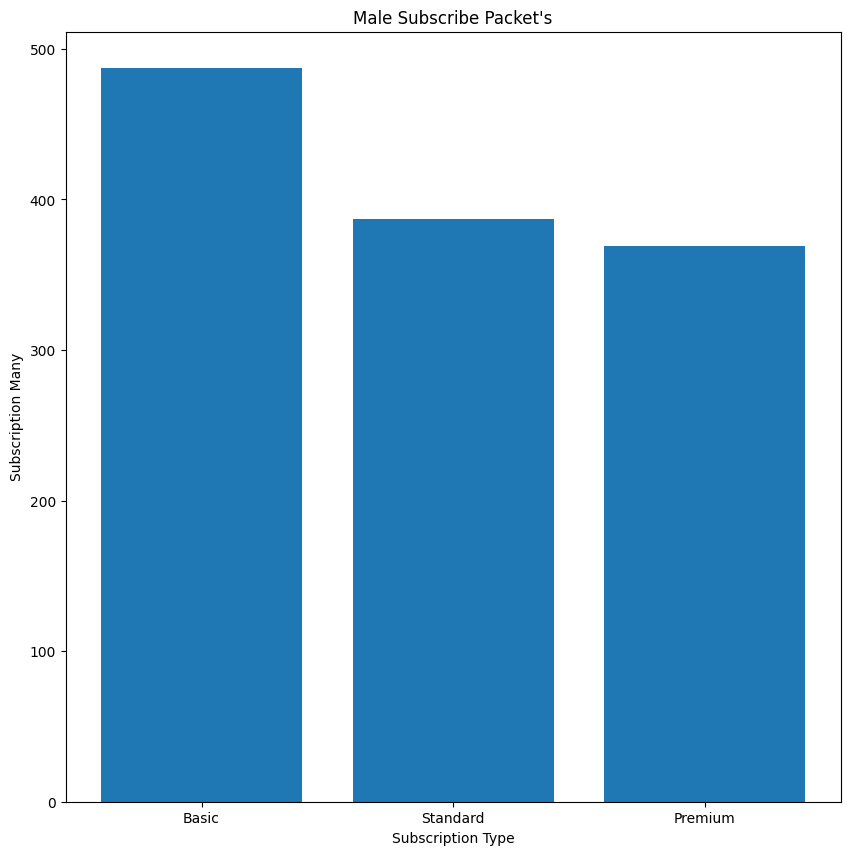

In [193]:
plt.figure(figsize=(10,10))
plt.title("Male Subscribe Packet's")
plt.xlabel("Subscription Type")
plt.ylabel("Subscription Many")
plt.bar(Male["subscription_type"].value_counts().index,Male["subscription_type"].value_counts().values)
plt.show()

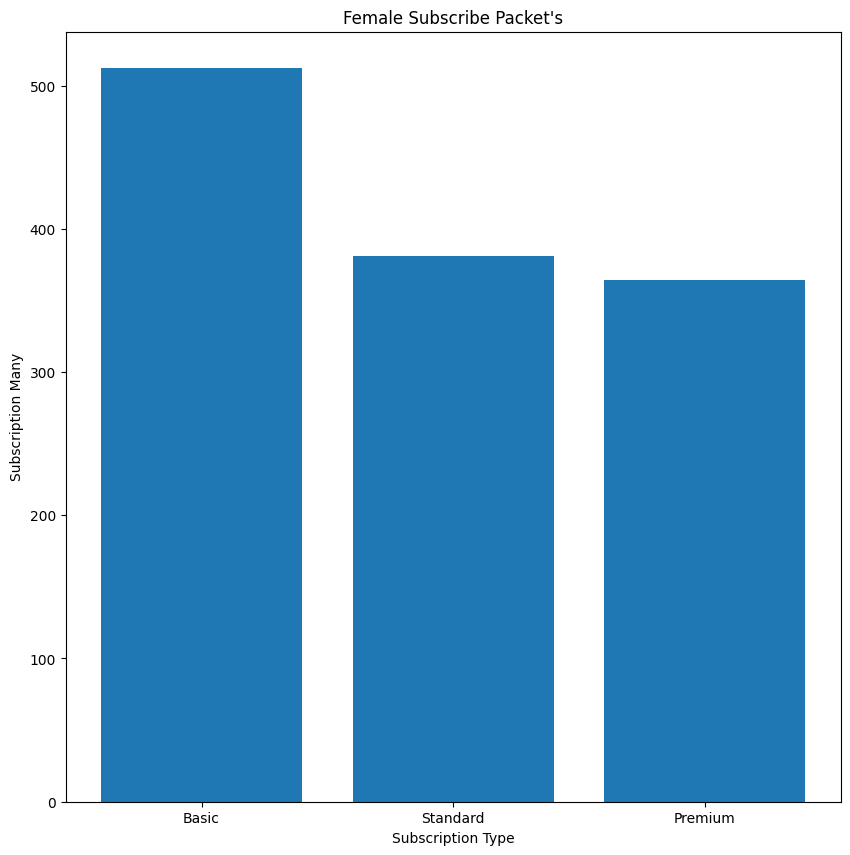

In [194]:
plt.figure(figsize=(10,10))
plt.title("Female Subscribe Packet's")
plt.xlabel("Subscription Type")
plt.ylabel("Subscription Many")
plt.bar(Female["subscription_type"].value_counts().index,Female["subscription_type"].value_counts().values)
plt.show()

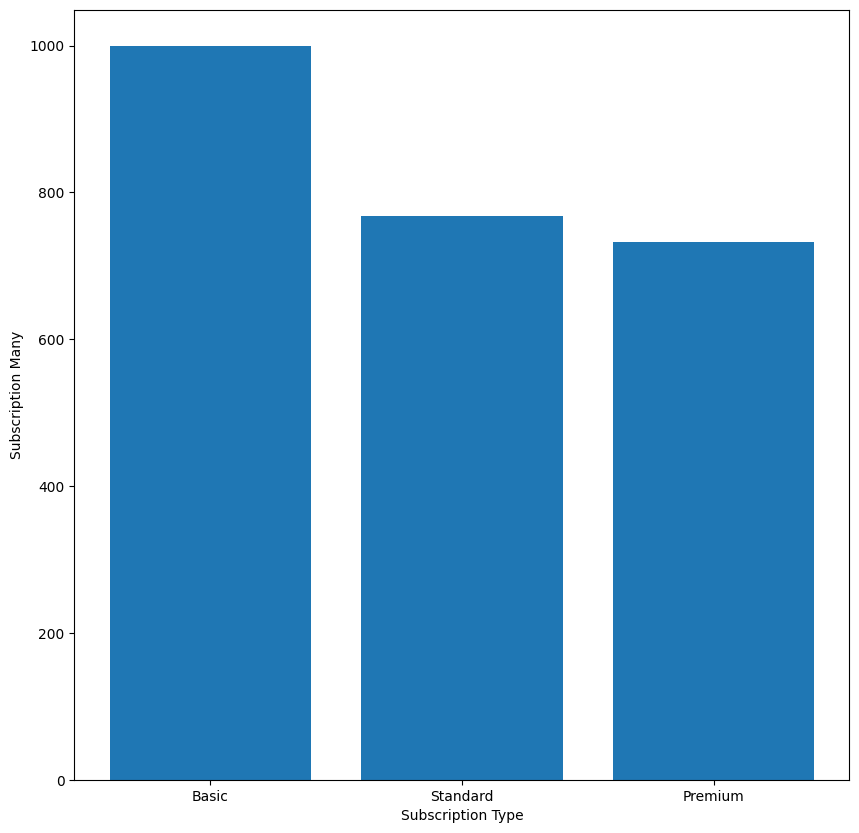

In [195]:
df[["subscription_type"]]
plt.figure(figsize=(10,10))
plt.xlabel("Subscription Type")
plt.ylabel("Subscription Many")
plt.bar(df["subscription_type"].value_counts().index,df["subscription_type"].value_counts().values)
plt.show()

In [ ]:
##General Analysis 📊
#Users usually use basic plan.Standart and Premium plan users almost same.

##Key Finding 🔑

#Basic Plan Users : %39,96
#Standart Plan Users: %30,72
#Premium Plan Users: %29,32

## Analysis 🔎

#Roughly Users %70 use netflix for personel and max 2 person.
#This show we most of the users are single and small family.

## Gender Analysis 🙍🏼‍♂️🙎🏼‍♀️

#The female netflix users more male netflix users.
#Standart and Premium plan users almost same.
#Female basic plan users more male basic plan users.

General Subscription Anaylsis

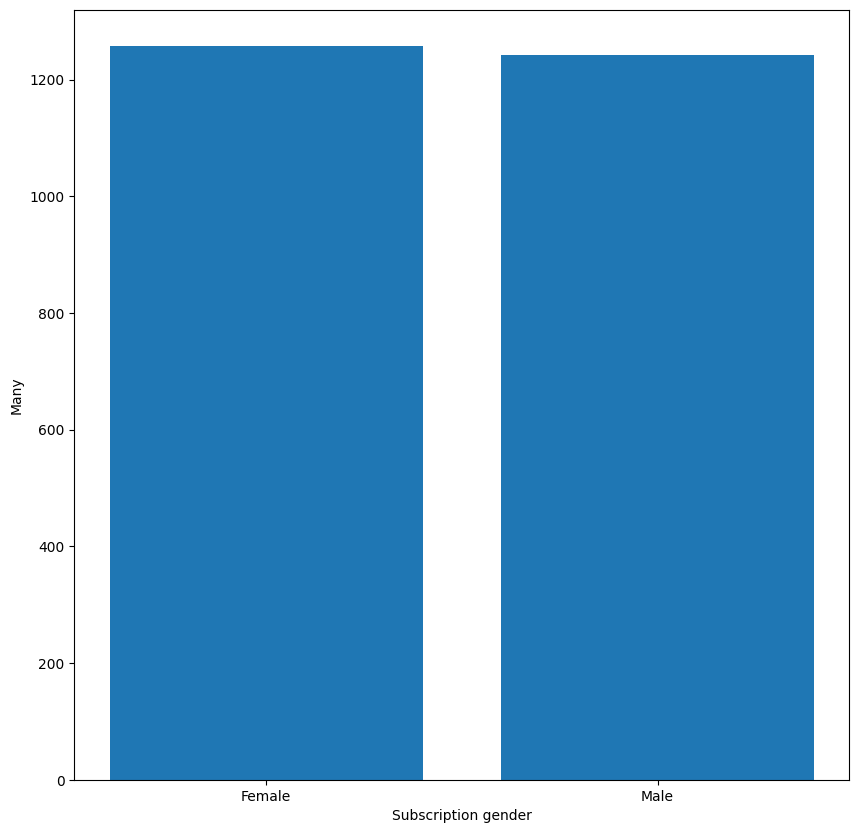

In [196]:
df["gender"].describe()
plt.figure(figsize=(10,10))
plt.xlabel("Subscription gender")
plt.ylabel("Many")
plt.bar(df["gender"].value_counts().index,df["gender"].value_counts().values)
plt.show()

In [197]:
df["country"].describe()

count              2500
unique               10
top       United States
freq                451
Name: country, dtype: object

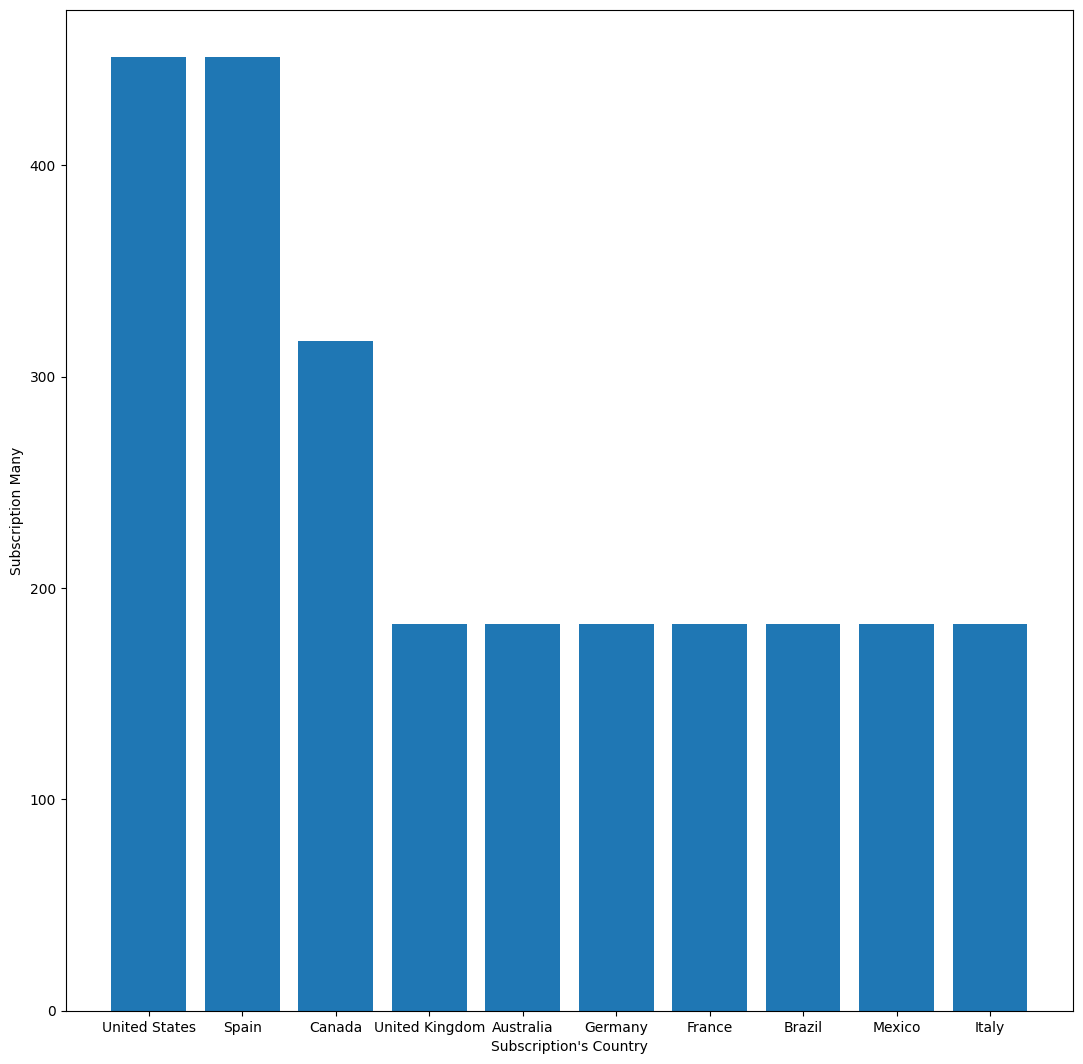

In [198]:
df[["subscription_type","country"]].groupby("country")
plt.figure(figsize=(13,13))
plt.xlabel("Subscription's Country")
plt.ylabel("Subscription Many")
plt.bar(df["country"].value_counts().index,df["country"].value_counts().values)
plt.show()

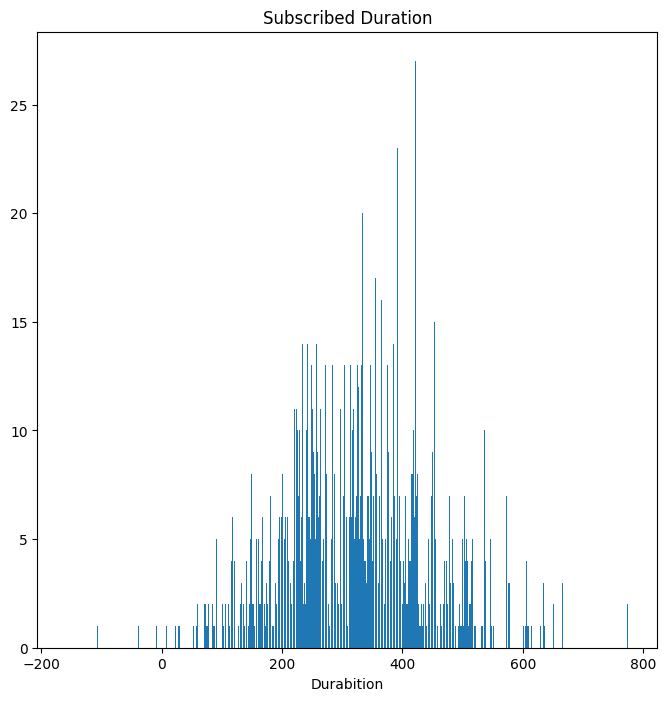

In [206]:
df[["subscribed_duration"]]
plt.figure(figsize=(8,8))
plt.title("Subscribed Duration")
plt.xlabel("Durabition")
plt.ylabel("")
plt.bar(df["subscribed_duration"].value_counts().index,df["subscribed_duration"].value_counts().values)
plt.show()

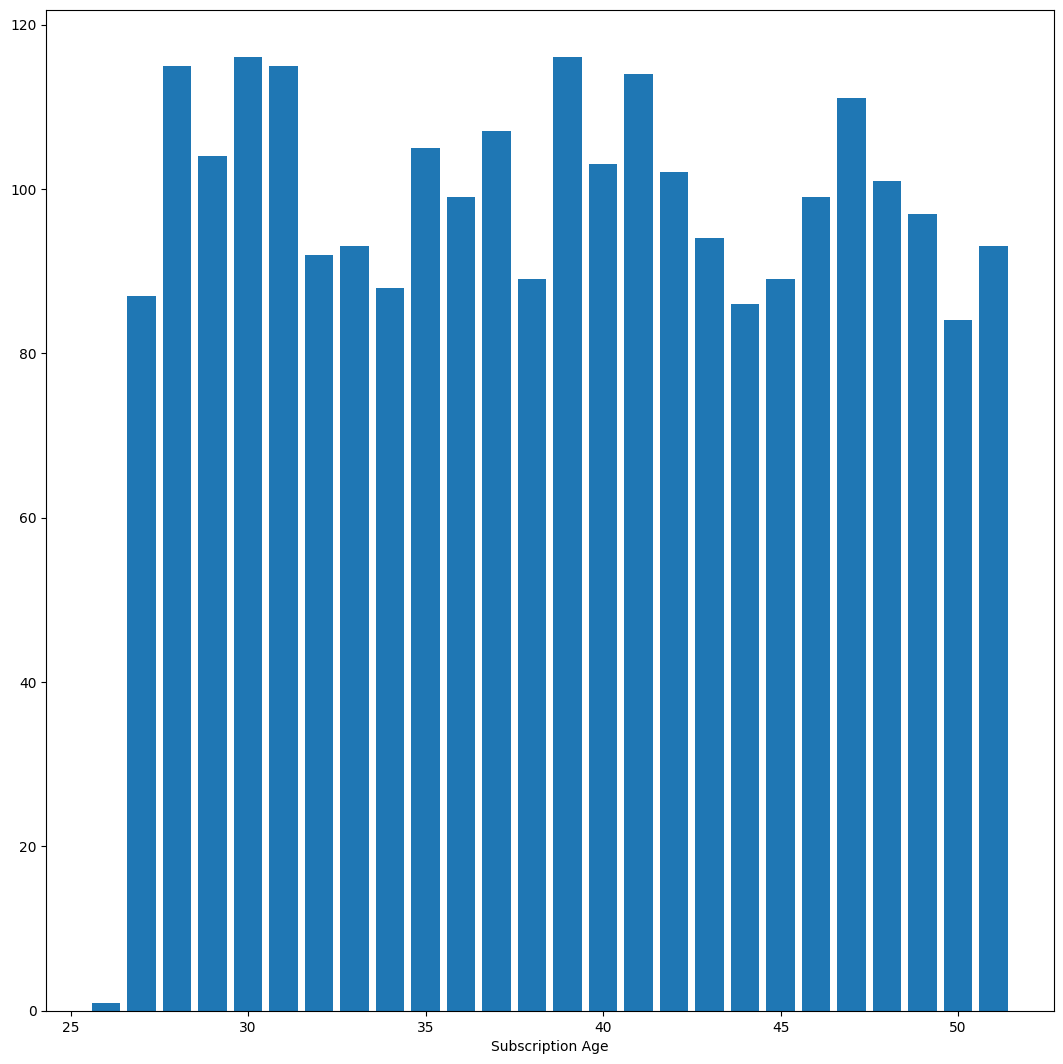

In [200]:
df[["age","subscription_type"]].groupby("age")
plt.figure(figsize=(13,13))
plt.xlabel("Subscription Age")
plt.ylabel("")
plt.bar(df["age"].value_counts().index,df["age"].value_counts().values)
plt.show()

In [201]:
df["device"].describe()

count       2500
unique         4
top       Laptop
freq         636
Name: device, dtype: object

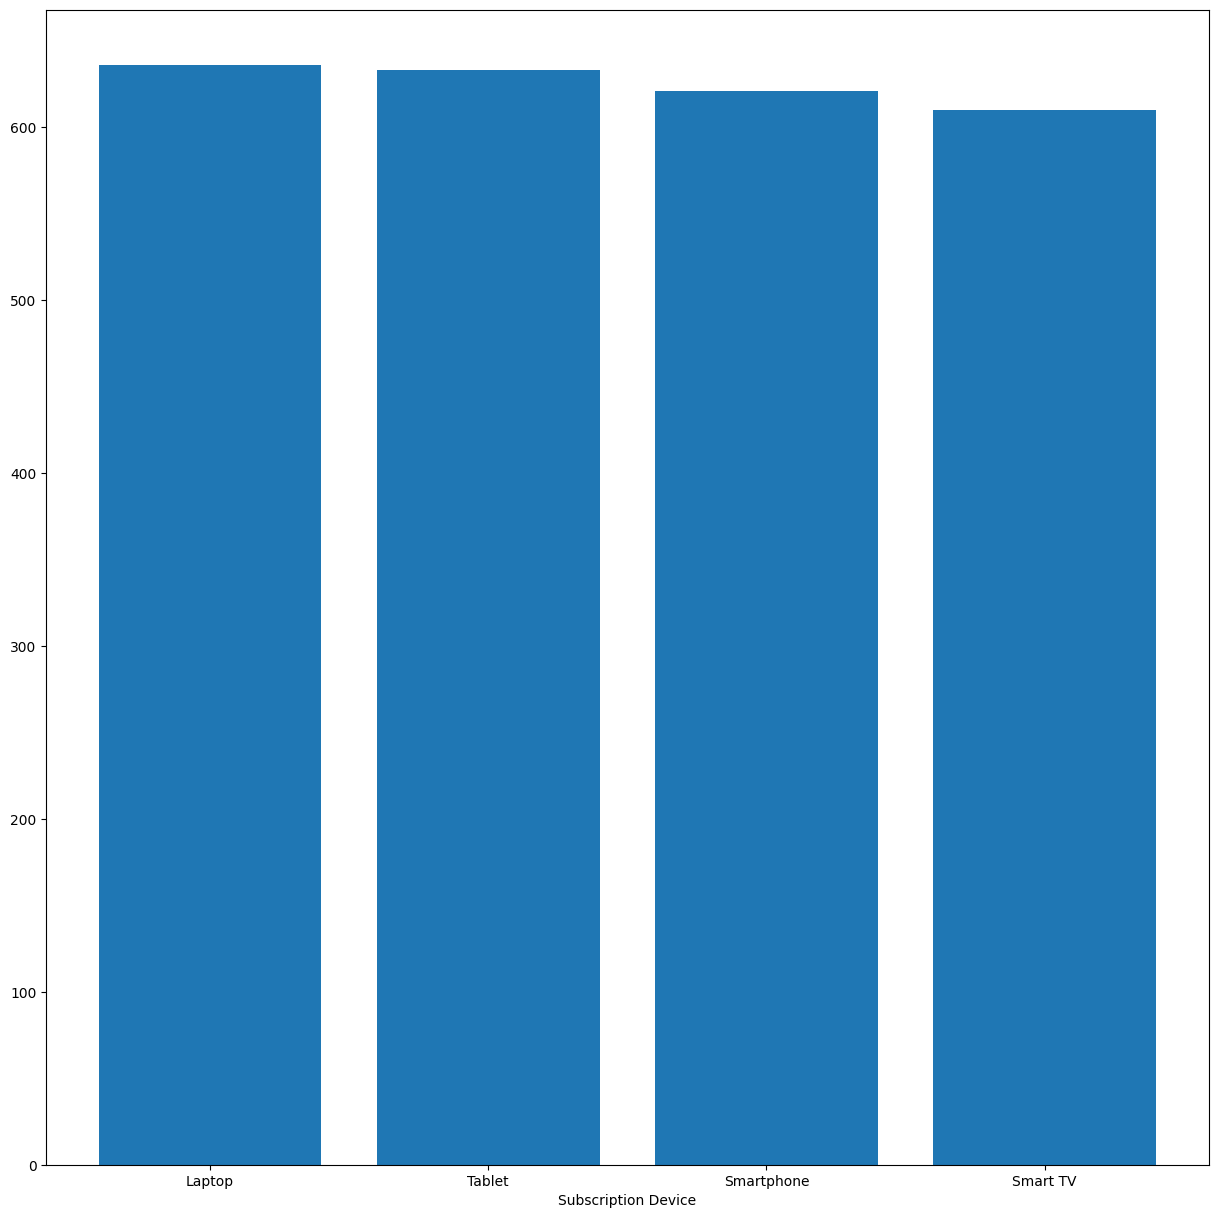

In [202]:
df[["subscription_type","device"]].groupby("device")
plt.figure(figsize=(15,15))
plt.xlabel("Subscription Device")
plt.ylabel("")
plt.bar(df["device"].value_counts().index,df["device"].value_counts().values)
plt.show()

In [ ]:
# ## 🌍 Country Distribution
# * The top 3 countries with the most Netflix users, in order: **United States**, **Spain**, and **Canada**.

# ---

# ## 🎂 Age Demographics
# * **Minimum Age:** 26
# * **Maximum Age:** 51
# * **Average (Mean) Age:** ~39 years old

# ### 🧠 Age Analysis:
# Most of our users' ages change between 31 and 45. This shows us that the standard deviation is around 7 years. 
# There are no very young or very old users; our target audience is mostly middle-aged.

# ---

# ## 💻 Device Preferences
# Our users' device preferences are literally balanced. 

# * The most used devices, in order: **Laptop**, **Tablet**, **Smartphone**, and **Smart TV**.
# * **Smart TV** is the use very little.
# On average, users pay for 316 days of subscription fee.

##Detailed Analysis by Country 📊

United States Detailed Analysis 📊📈


In [23]:
america = df[df["country"] == "United States"]

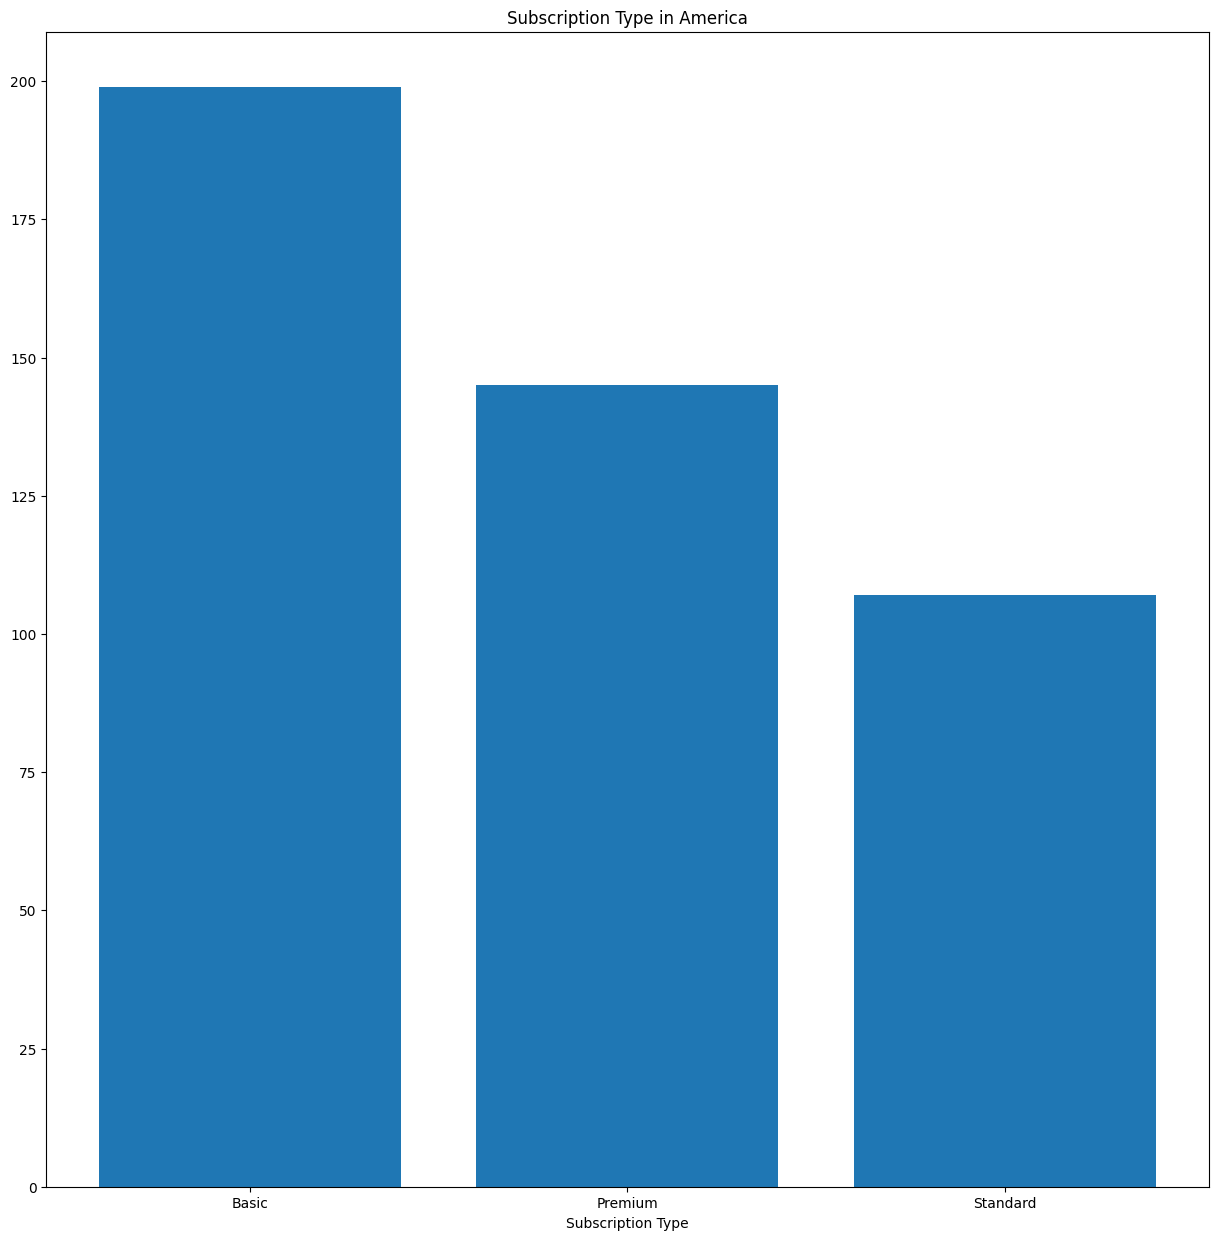

In [ ]:
america[["subscription_type"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription Plan Type in America")
plt.xlabel("Subscription Plan Type")
plt.ylabel("")
plt.bar(america["subscription_type"].value_counts().index,america["subscription_type"].value_counts().values)
plt.show()

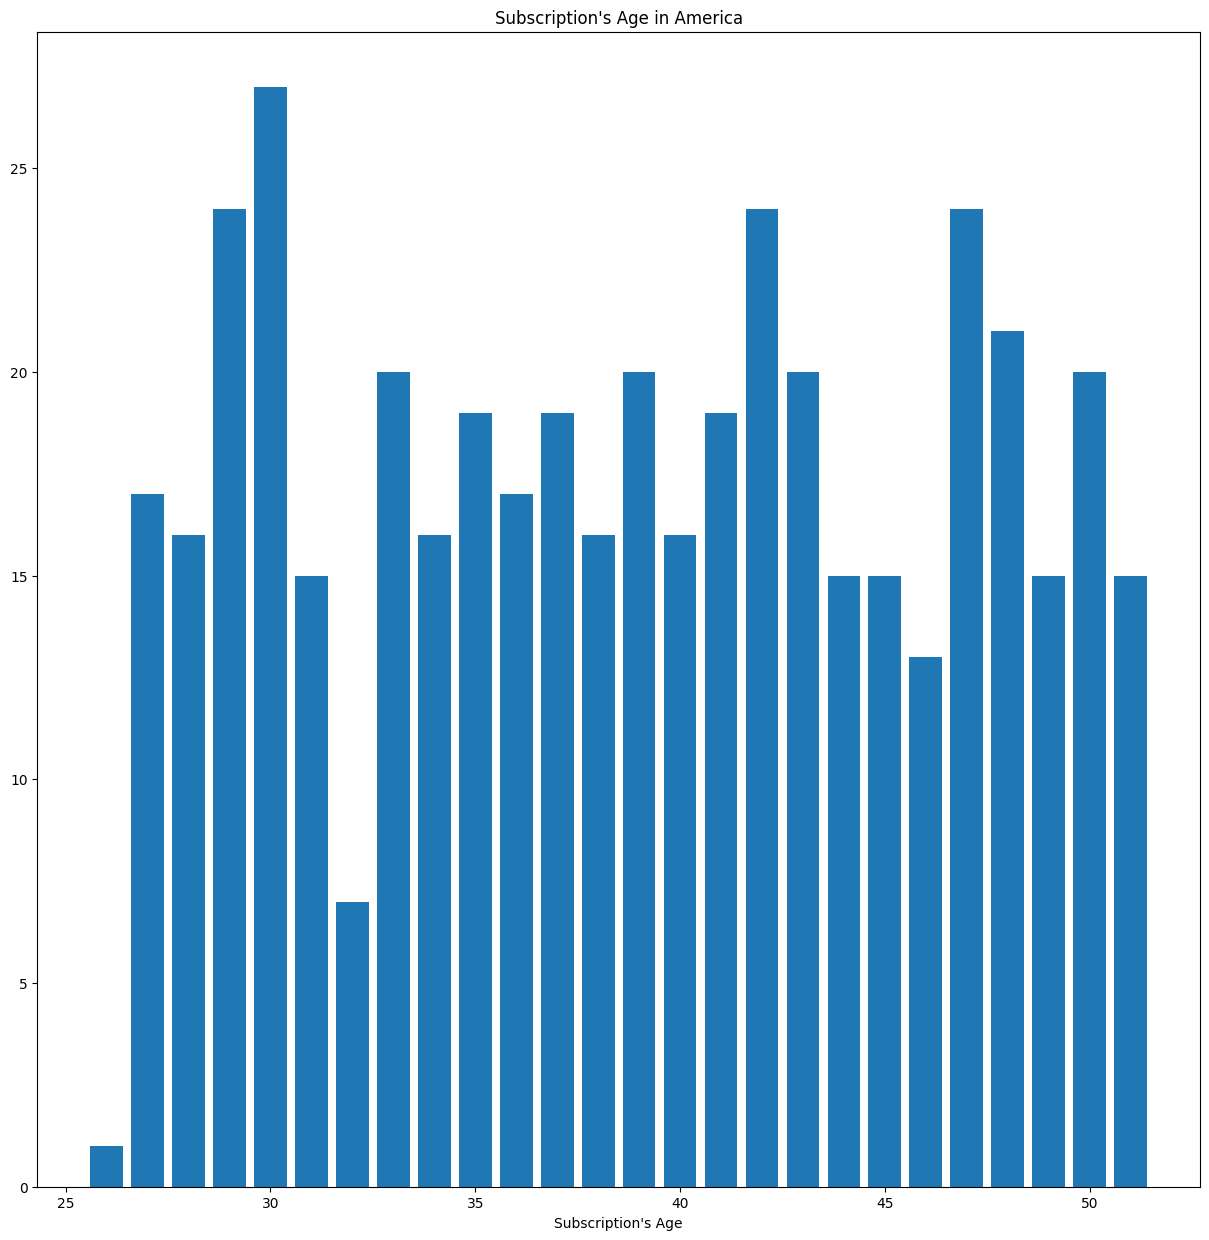

In [19]:
america[["age"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Age in America")
plt.xlabel("Subscription's Age")
plt.ylabel("")
plt.bar(america["age"].value_counts().index,america["age"].value_counts().values)
plt.show()

In [44]:
america[["age"]].mean()

age    38.926829
dtype: float64

In [45]:
america[["age"]].std()

age    7.242864
dtype: float64

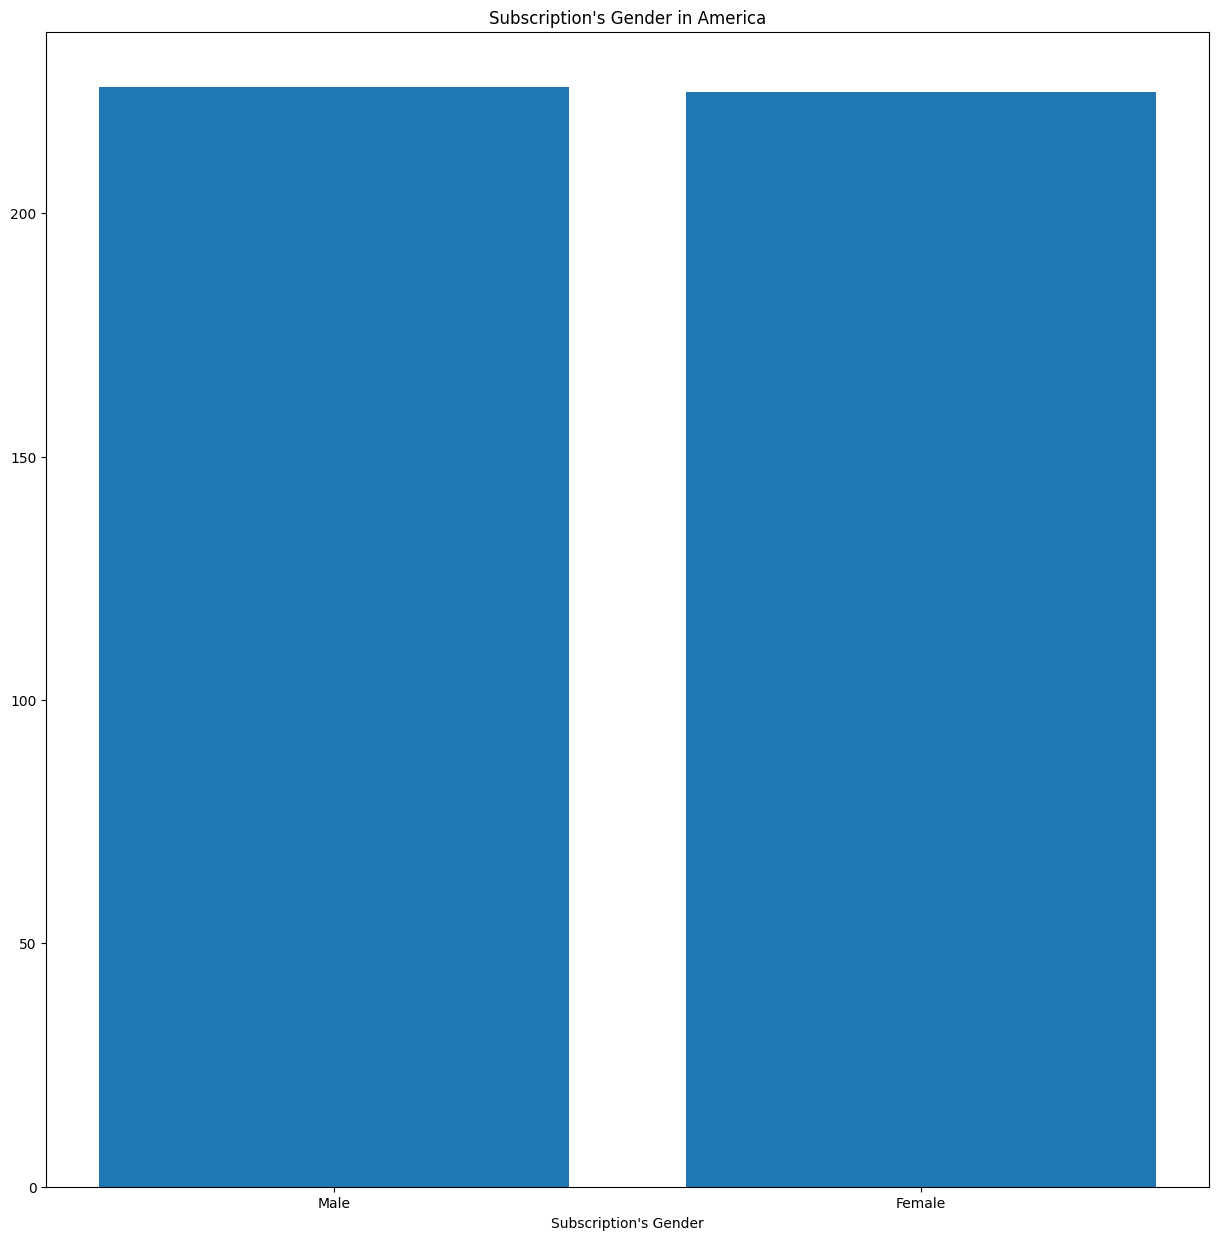

In [18]:
america[["gender"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Gender in America")
plt.xlabel("Subscription's Gender")
plt.ylabel("")
plt.bar(america["gender"].value_counts().index,america["gender"].value_counts().values)
plt.show()

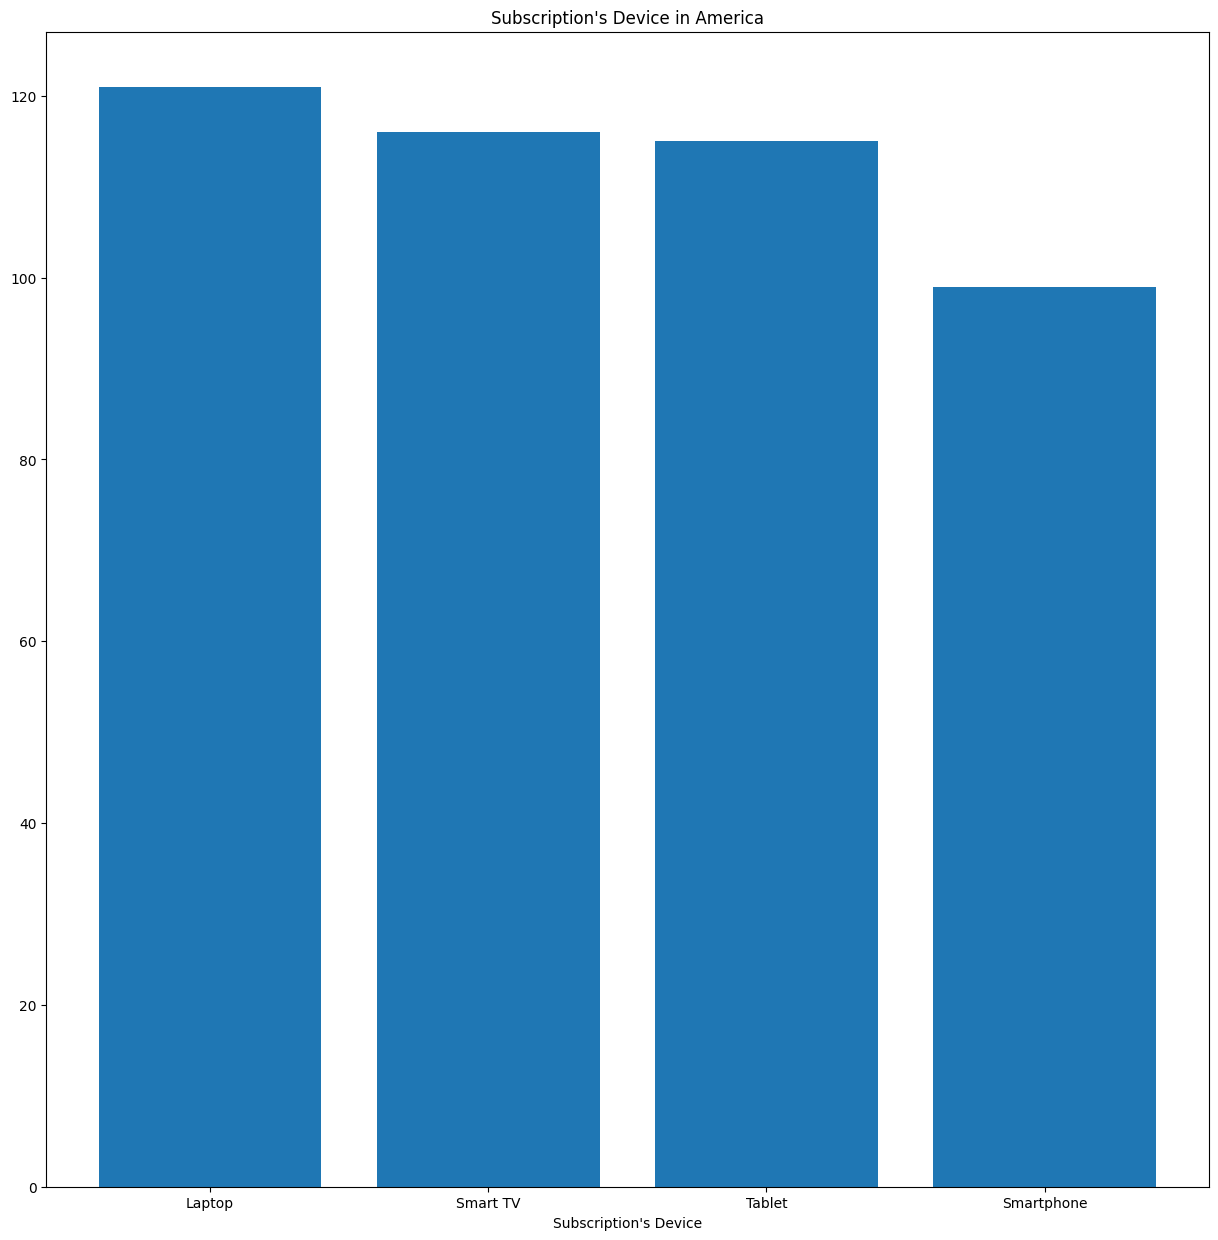

In [ ]:
america[["device"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Device in America")
plt.xlabel("Subscription's Device")
plt.ylabel("")
plt.bar(america["device"].value_counts().index,america["device"].value_counts().values)
plt.show()

In [43]:
america[["device"]].count()

device    451
dtype: int64

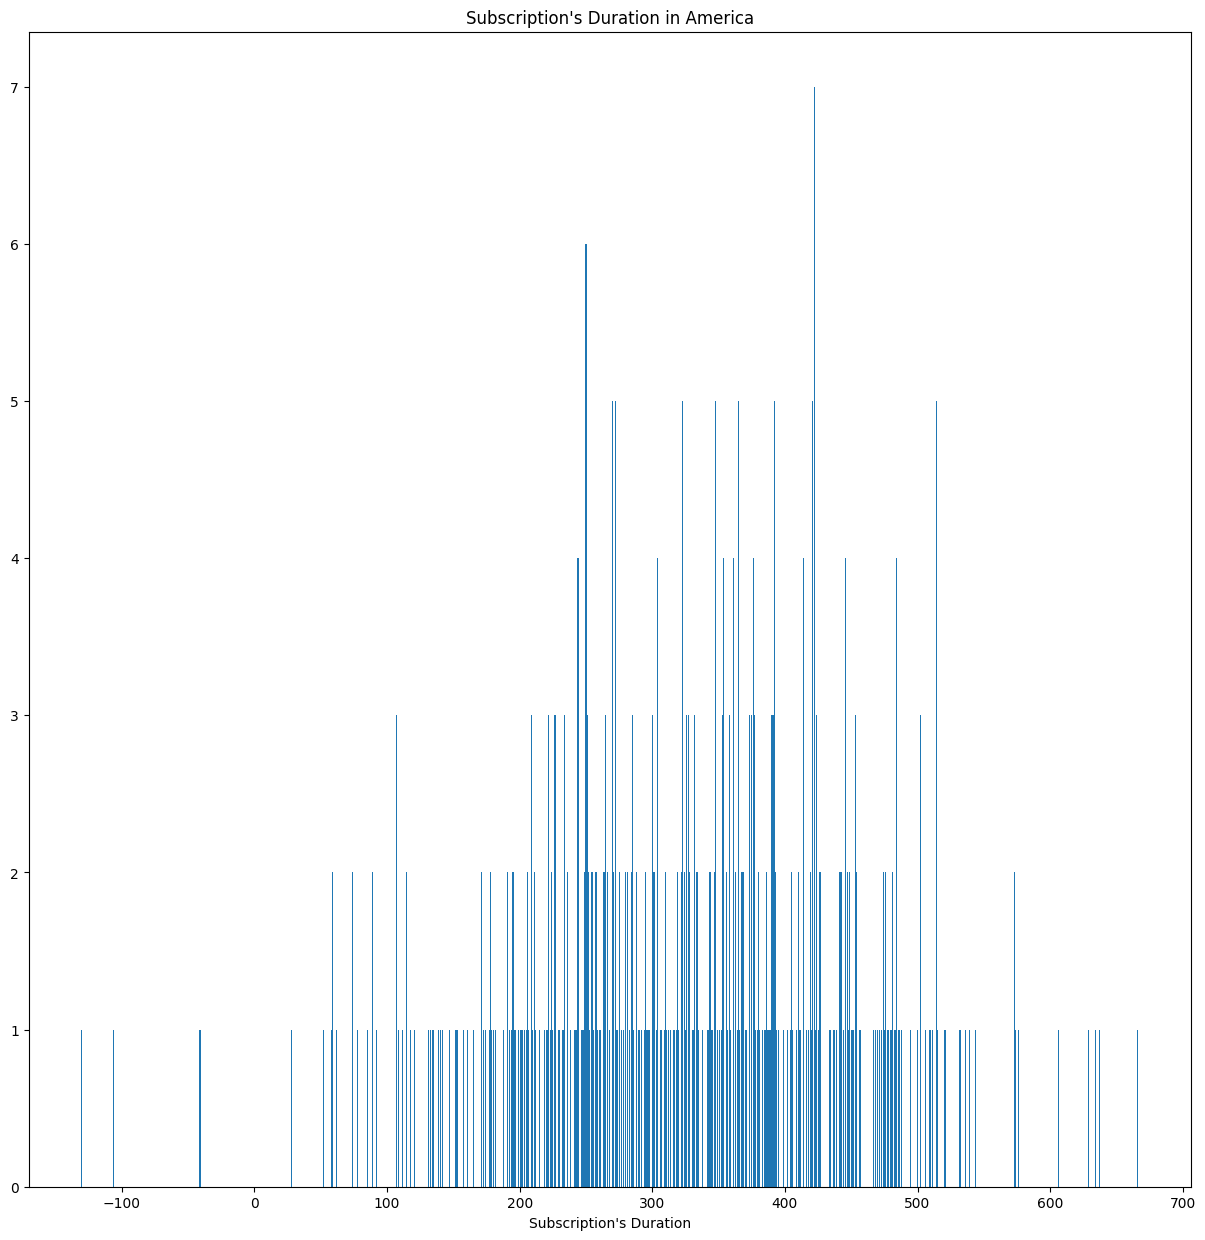

In [22]:
america[["subscribed_duration"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Duration in America")
plt.xlabel("Subscription's Duration")
plt.ylabel("")
plt.bar(america["subscribed_duration"].value_counts().index,america["subscribed_duration"].value_counts().values)
plt.show()

In [39]:
america[["subscribed_duration"]].mean()

subscribed_duration    325.039911
dtype: float64

In [38]:
america[["subscribed_duration"]].std()

subscribed_duration    118.874512
dtype: float64

In [24]:
america[["start_month"]].value_counts()

start_month
July           76
October        73
June           60
August         59
September      57
April          25
November       23
March          20
January        16
February       16
May            15
December       11
Name: count, dtype: int64

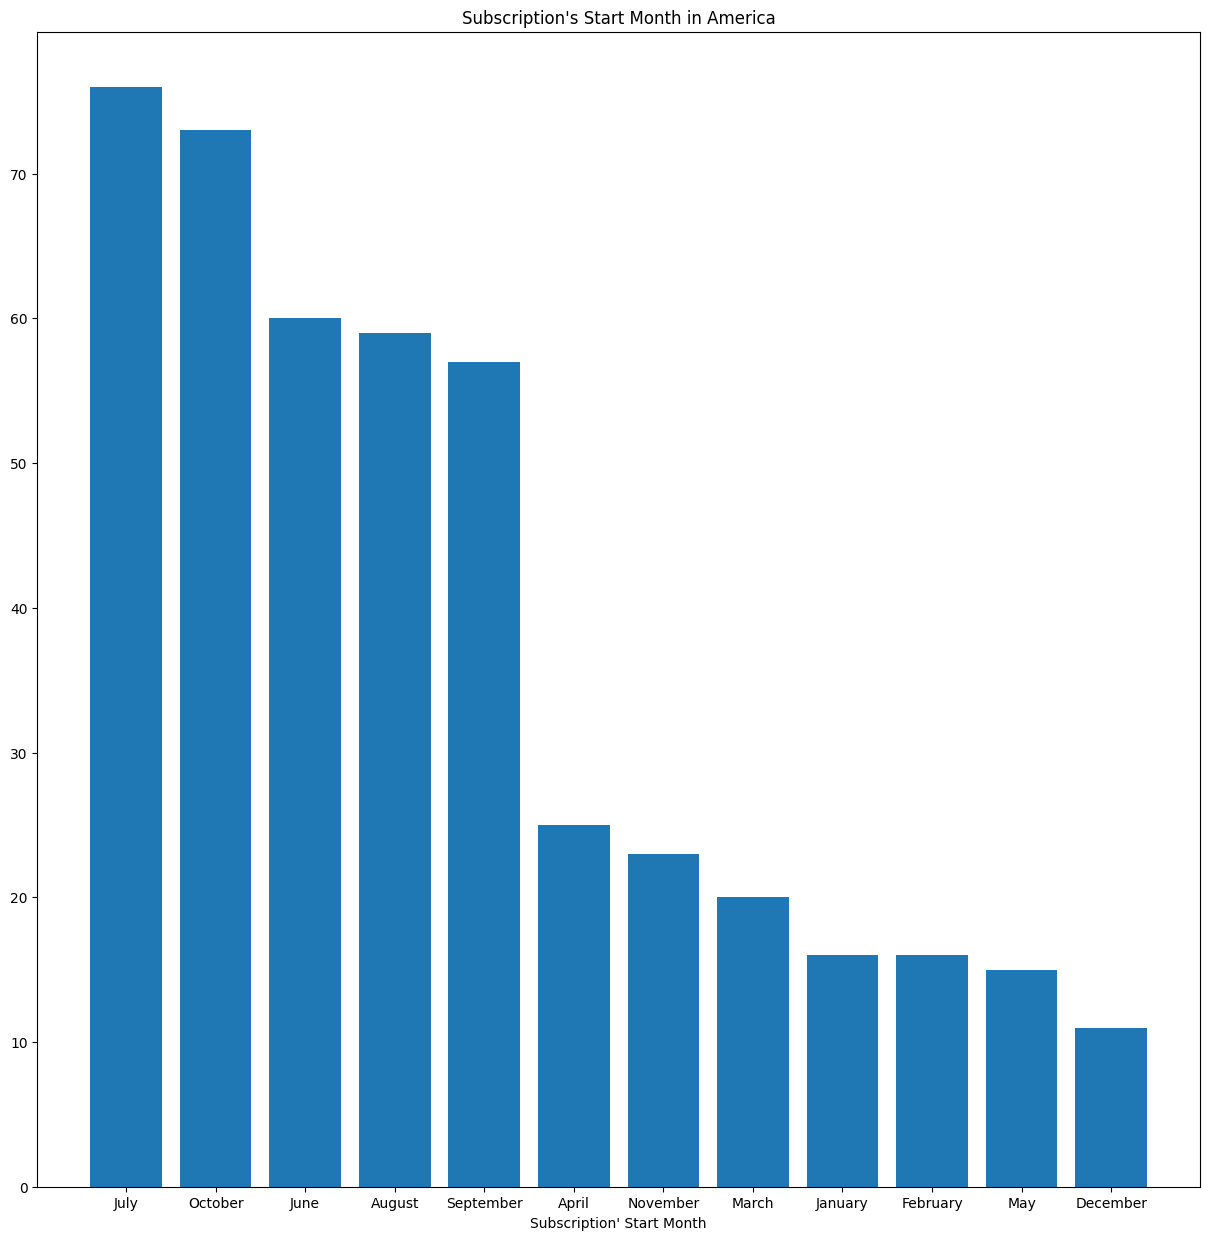

In [25]:
america[["start_month"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Start Month in America")
plt.xlabel("Subscription' Start Month")
plt.ylabel("")
plt.bar(america["start_month"].value_counts().index,america["start_month"].value_counts().values)
plt.show()

In [ ]:
america[["clv"]].mean()


clv    4091.332594
dtype: float64

In [40]:
america[["clv"]].std()

clv    1623.891302
dtype: float64

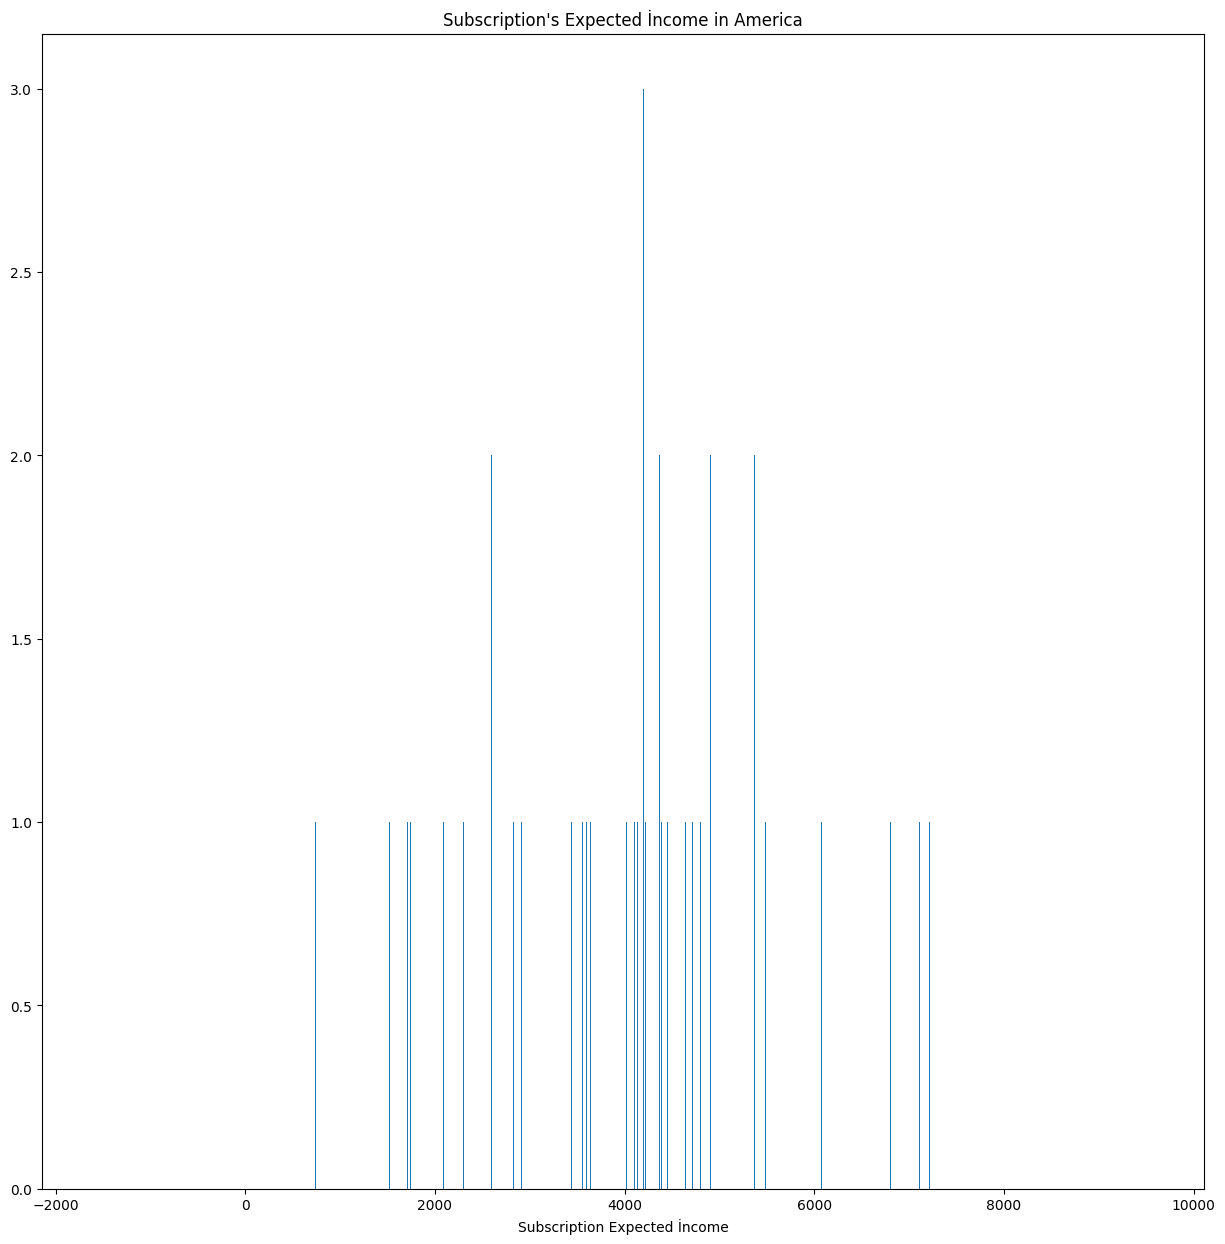

In [34]:
america[["clv"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Expected İncome in America")
plt.xlabel("Subscription Expected İncome"),
plt.ylabel("")
plt.bar(america["clv"].value_counts().index,america["clv"].value_counts().values)
plt.show()

In [ ]:
## Subscription Type in America 💰

#Subscribers prefer most of the basic plan then premium plan and standart plan(This is weird).

## Subscribers Age and Gender Analysis 🙍🏼‍♀️🙍🏼‍♂️

#Subscribers gender distribution is almost the same.
#Subscribers mean age is 38,standart deviation 7.Age distribution is ranges between 31-45.

## Subscribers Device Analysis 📱

#Netflix users the most used device is by order:"Laptop,Smart TV,Tablet,Phone". 

## Subscription Duration Analysis 🛡

#Subscriptions duration mean is 325 days.Standart diviation is 118.
#Subscriptions duration ranges between 207-443 days.

## Subscription Start Date Analysis ⏰

#Subscribers usually joined first 5 months in netflix.

## Revenue Analysis Expected From Subscribers(Netflix) 💰

#Expected revenue mean is 4000 💲.Standart diviation is 1623 💲.
#Expected revenue ranges between is 2377-5623.

In [ ]:
#For short
#America very avalaible investment for netflix.

Spain Detailed Analysis 📊📈

In [5]:
spain = df[df["country"] == "Spain"]

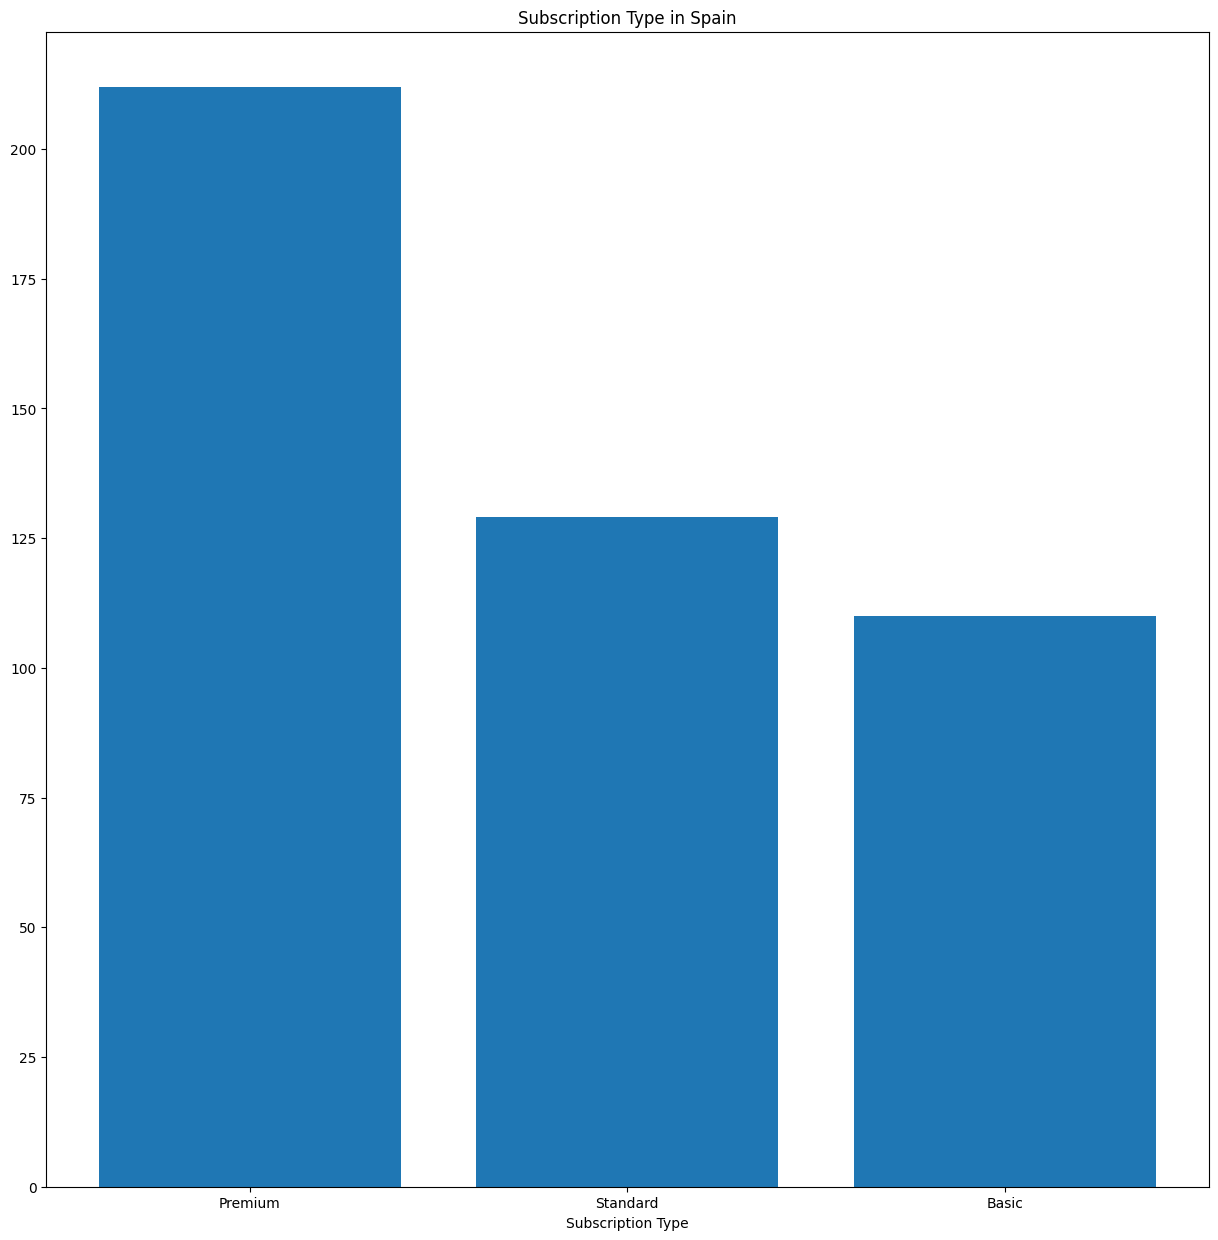

In [ ]:
spain[["subscription_type"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription Plan Type in Spain")
plt.xlabel("Subscription Plan Type")
plt.ylabel("")
plt.bar(spain["subscription_type"].value_counts().index,spain["subscription_type"].value_counts().values)
plt.show()

In [10]:
spain[["age"]].mean()

age    38.800443
dtype: float64

In [11]:
spain[["age"]].std()

age    7.46042
dtype: float64

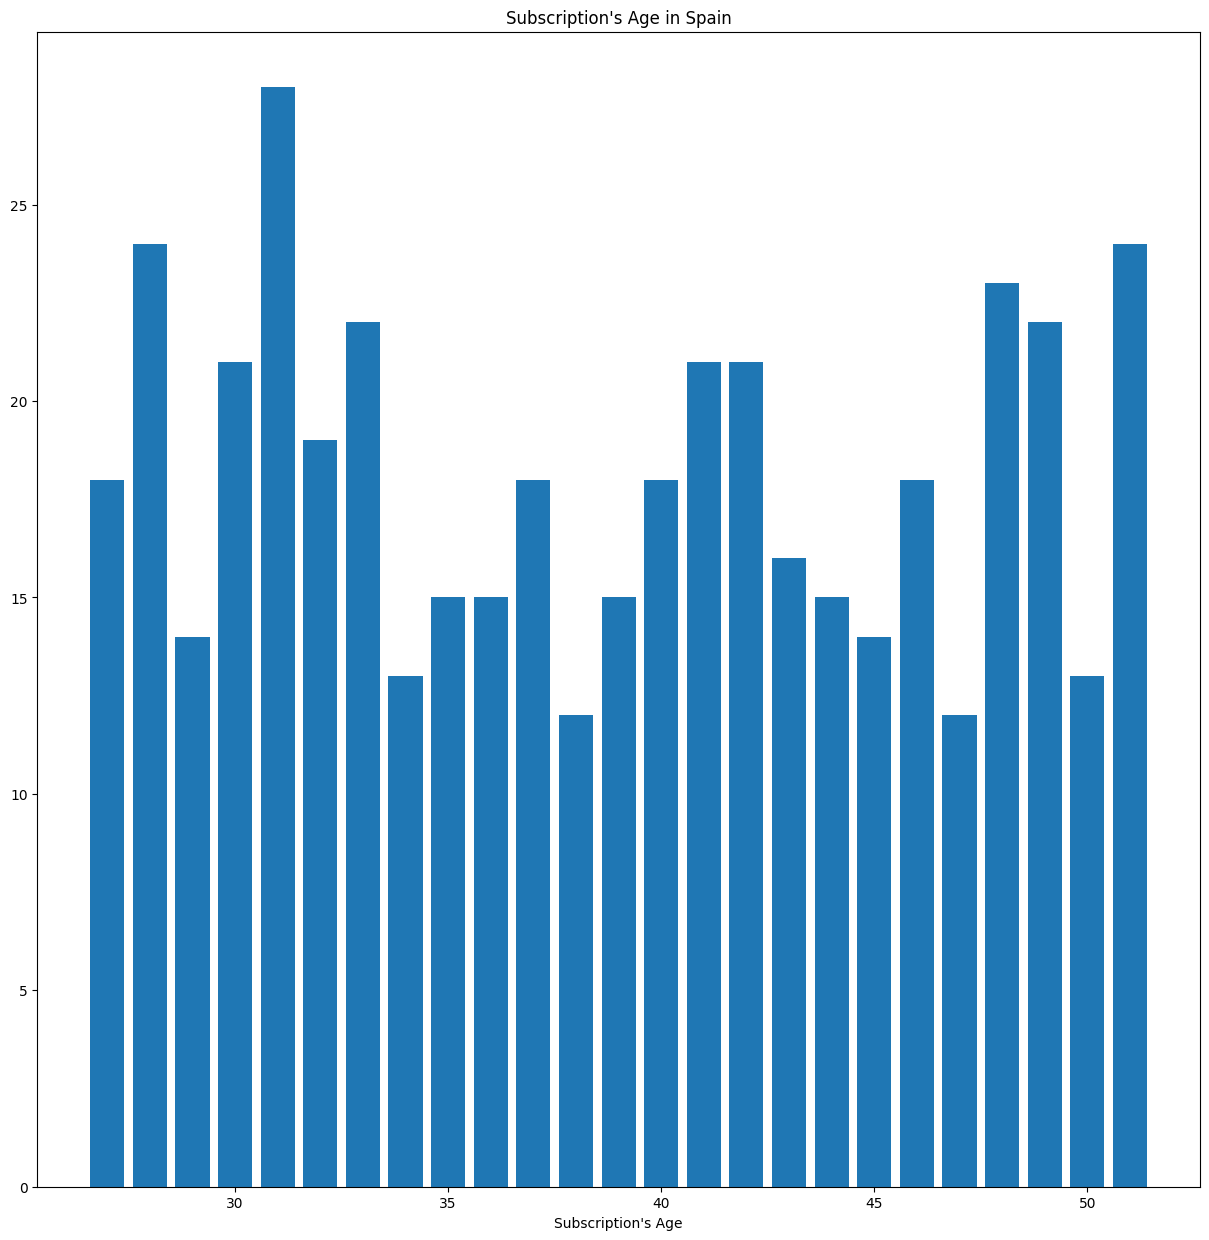

In [12]:
spain[["age"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Age in Spain")
plt.xlabel("Subscription's Age")
plt.ylabel("")
plt.bar(spain["age"].value_counts().index,spain["age"].value_counts().values)
plt.show()

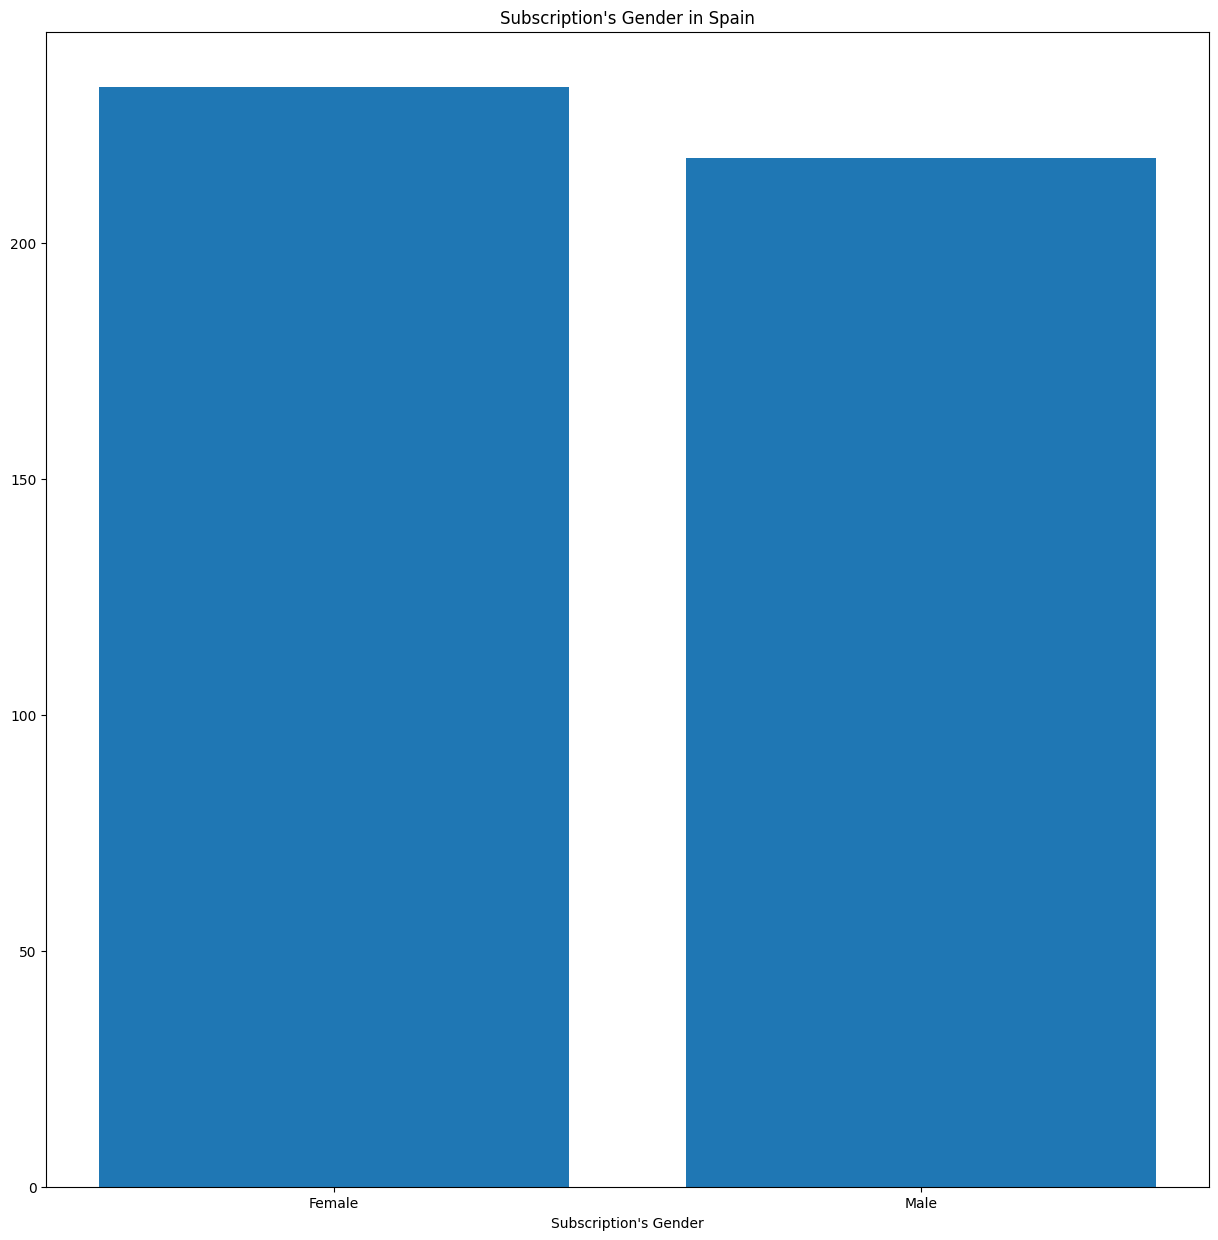

In [14]:
spain[["gender"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Gender in Spain")
plt.xlabel("Subscription's Gender")
plt.ylabel("")
plt.bar(spain["gender"].value_counts().index,spain["gender"].value_counts().values)
plt.show()

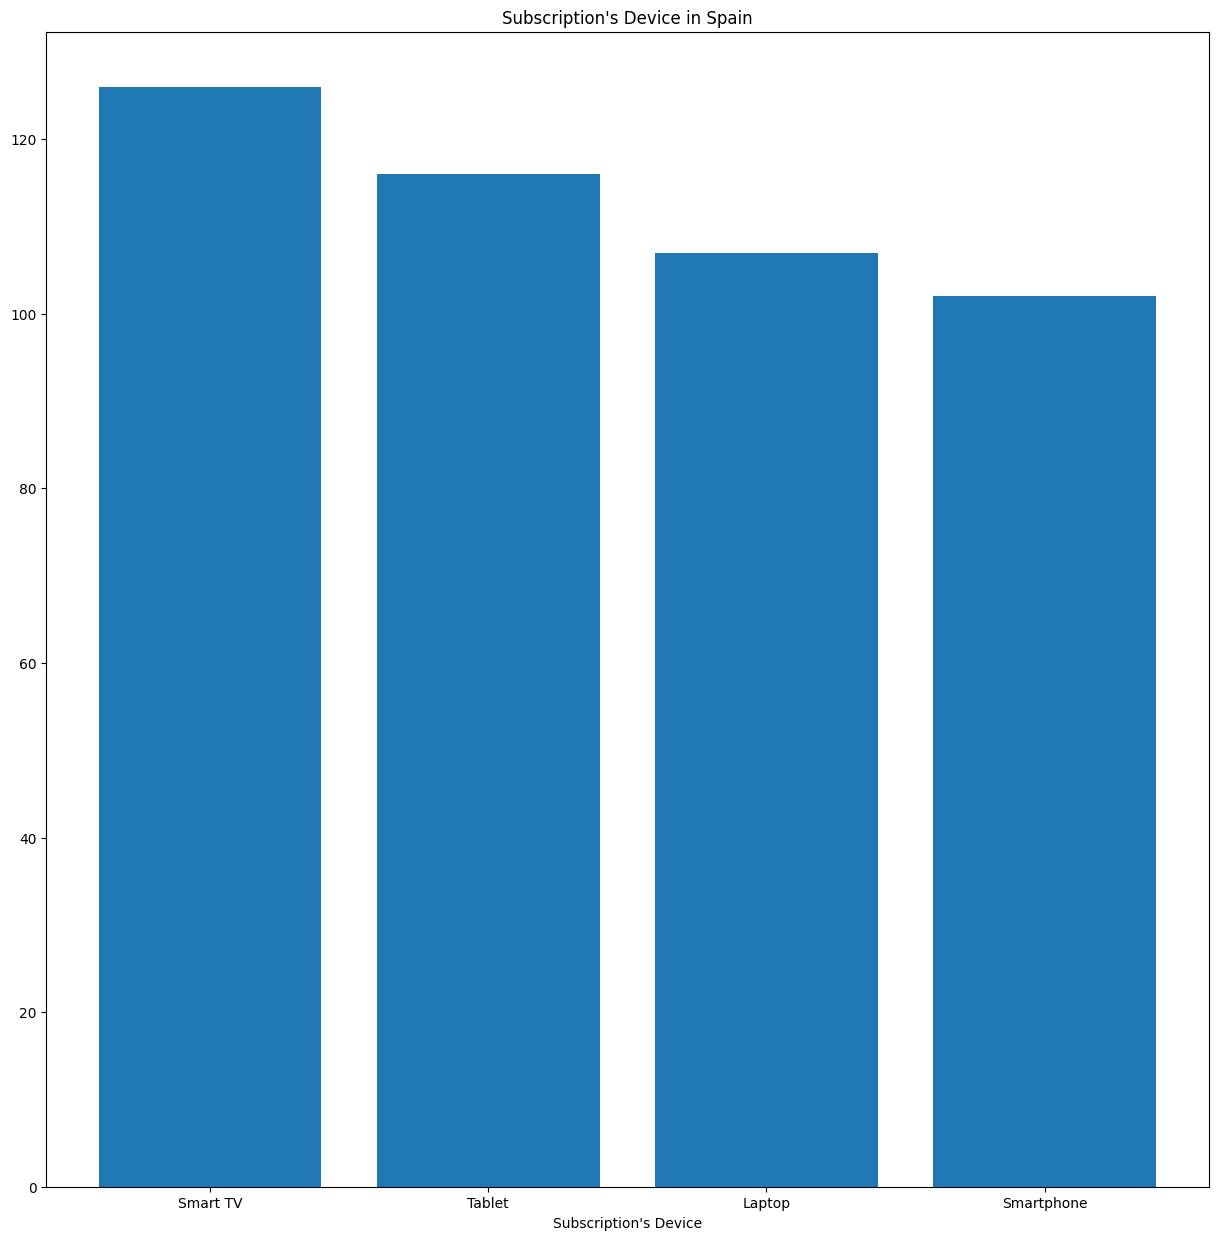

In [ ]:
spain[["device"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscribers Device in Spain")
plt.xlabel("Subscribers Device")
plt.ylabel("")
plt.bar(spain["device"].value_counts().index,spain["device"].value_counts().values)
plt.show()

In [17]:
spain[["subscribed_duration"]].mean()

NameError: name 'spain' is not defined

In [18]:
spain[["subscribed_duration"]].std()

subscribed_duration    114.256082
dtype: float64

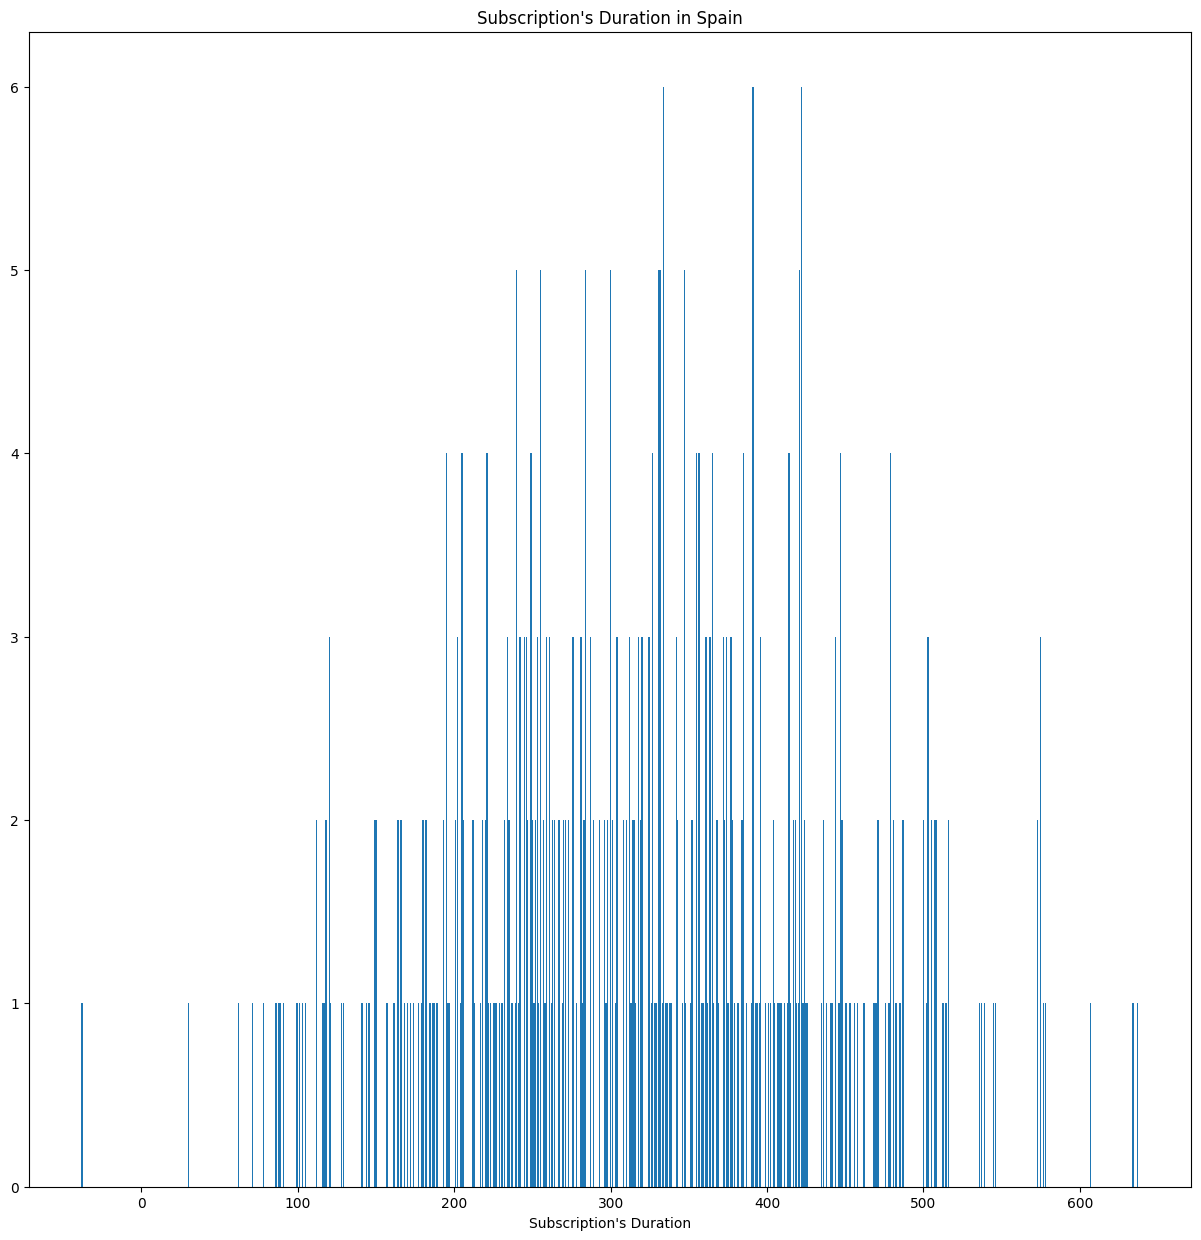

In [16]:
spain[["subscribed_duration"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Duration in Spain")
plt.xlabel("Subscription's Duration")
plt.ylabel("")
plt.bar(spain["subscribed_duration"].value_counts().index,spain["subscribed_duration"].value_counts().values)
plt.show()

In [21]:
spain[["start_month"]].value_counts()

start_month
October        91
July           74
June           67
August         54
September      49
December       22
February       18
May            18
November       16
April          15
January        14
March          13
Name: count, dtype: int64

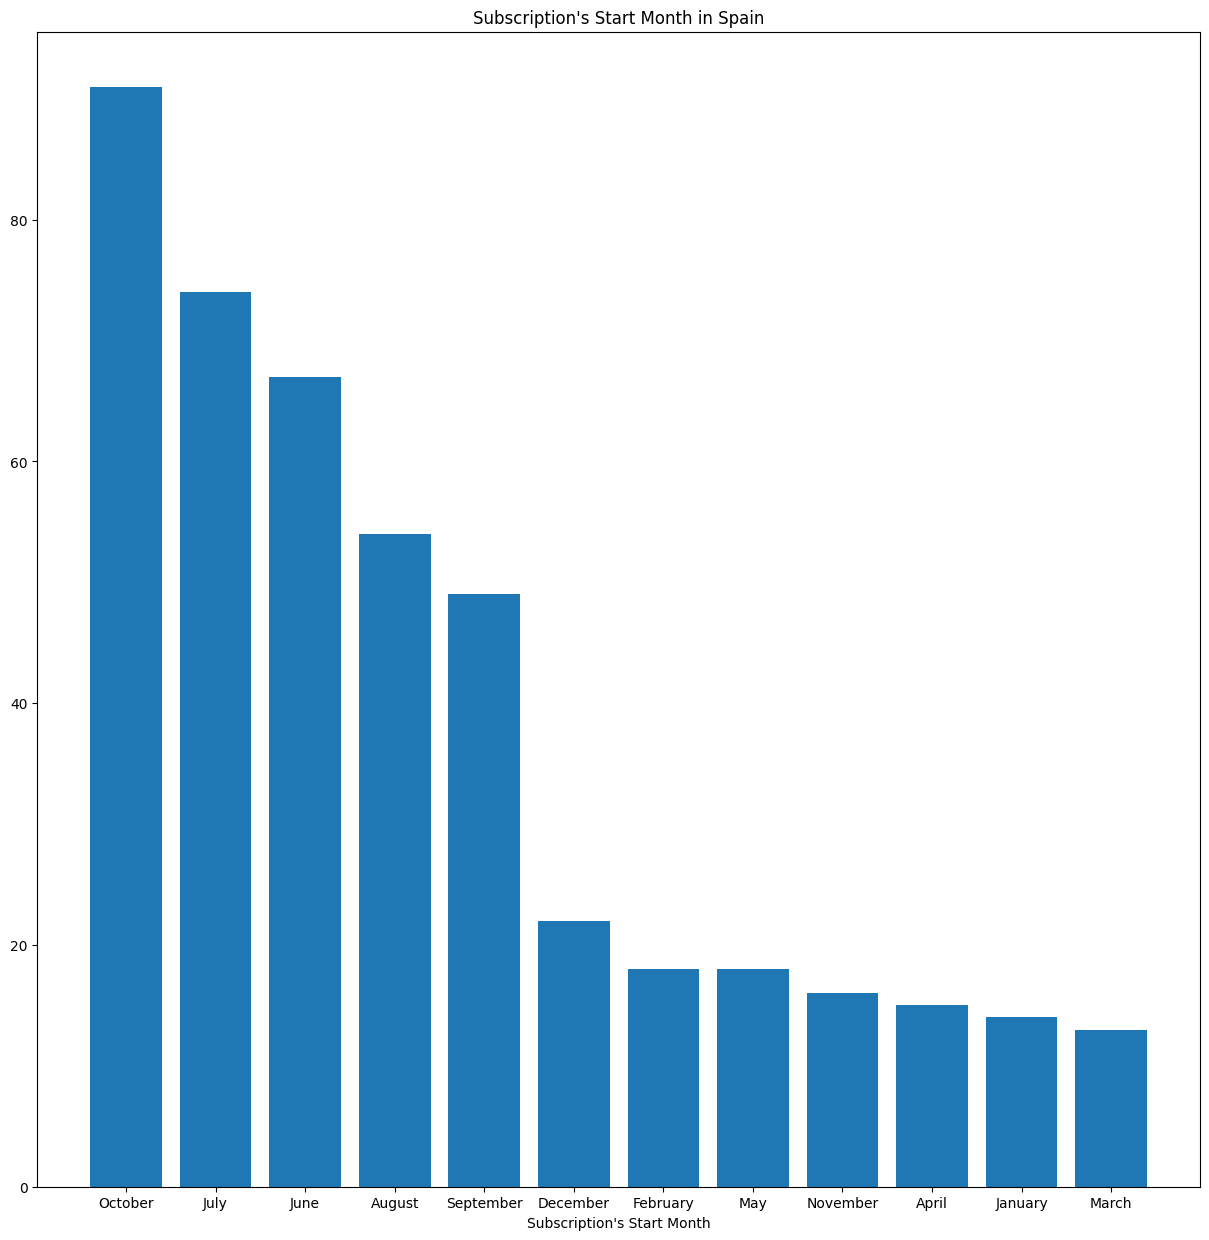

In [ ]:
spain[["start_month"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscribers Start Month in Spain")
plt.xlabel("Subscribers Start Month")
plt.ylabel("")
plt.bar(spain["start_month"].value_counts().index,spain["start_month"].value_counts().values)
plt.show()

In [26]:
spain[["clv"]].mean()

clv    4021.044346
dtype: float64

In [27]:
spain[["clv"]].std()

clv    1552.652998
dtype: float64

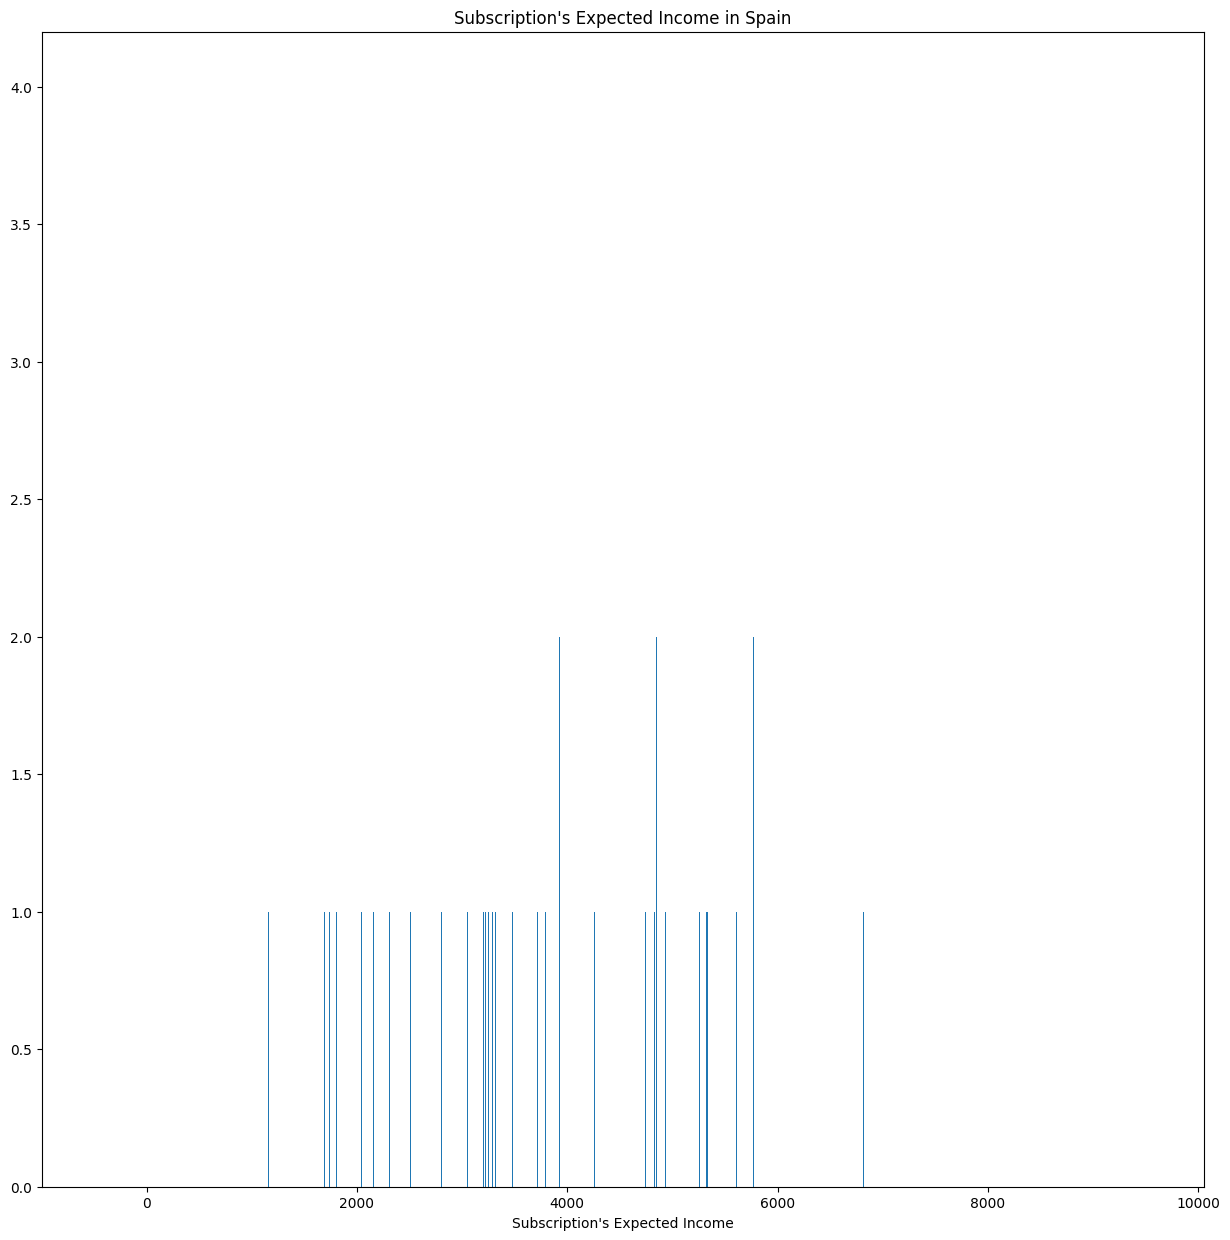

In [25]:
spain[["clv"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Expected Income in Spain")
plt.xlabel("Subscription's Expected Income")
plt.ylabel("")
plt.bar(spain["clv"].value_counts().index,spain["clv"].value_counts().values)
plt.show()

In [ ]:
## Subscription Type in Spain 💰

#Subscribed most of the prefer premium plan then standart and basic.

## Subscribers Age and Gender Analysis 🙍🏼‍♀️🙍🏼‍♂️

#There are more female subscribed than male subscribed.
#Subscribers mean age is 38,standart deviation 7.Age distribution is ranges between 31-45.

## Subscribers Device Analysis 📱

#Subscribers device distribution is order by:"Smart TV,Tablet,Laptop,Smartphone".(This is unexpected)

## Subscription Duration Analysis 🛡

#Subscribers average number of payment days 320 days.Standart diviation is 114.
#Subscribers number of payment days ranges between 206-434 days.

## Subscription Start Date Analysis ⏰

#Subscribers usually joined first 5 months in netflix.

## Revenue Analysis Expected From Subscribers(Netflix) 💰

#Expected revenue mean 4021 💲 from subscribers.Standart diviation is 1552 💲.
#Expected revenue ranges between 2469-5173 💲.

In [ ]:
#For short
#Spain effiency avalaible investment compared to other country.

Canada Detailed Analysis 📊

In [11]:
canada = df[df["country"] == "Canada"]

In [16]:
canada[["subscription_type"]].value_counts()

subscription_type
Basic                145
Premium               88
Standard              84
Name: count, dtype: int64

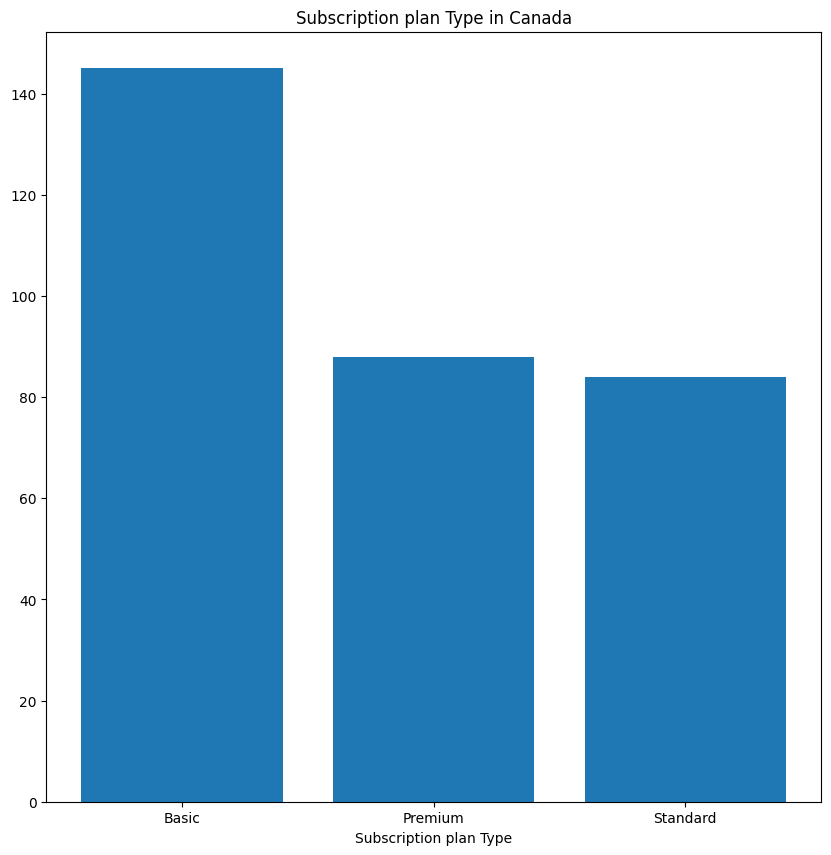

In [ ]:
canada[["subscription_type"]]
plt.figure(figsize=(10,10))
plt.title("Subscription plan Type in Canada")
plt.xlabel("Subscription plan Type")
plt.ylabel("")
plt.bar(canada["subscription_type"].value_counts().index,canada["subscription_type"].value_counts().values)
plt.show()

In [20]:
canada["age"].mean()

np.float64(38.69716088328076)

In [21]:
canada["age"].std()

np.float64(7.015563044068558)

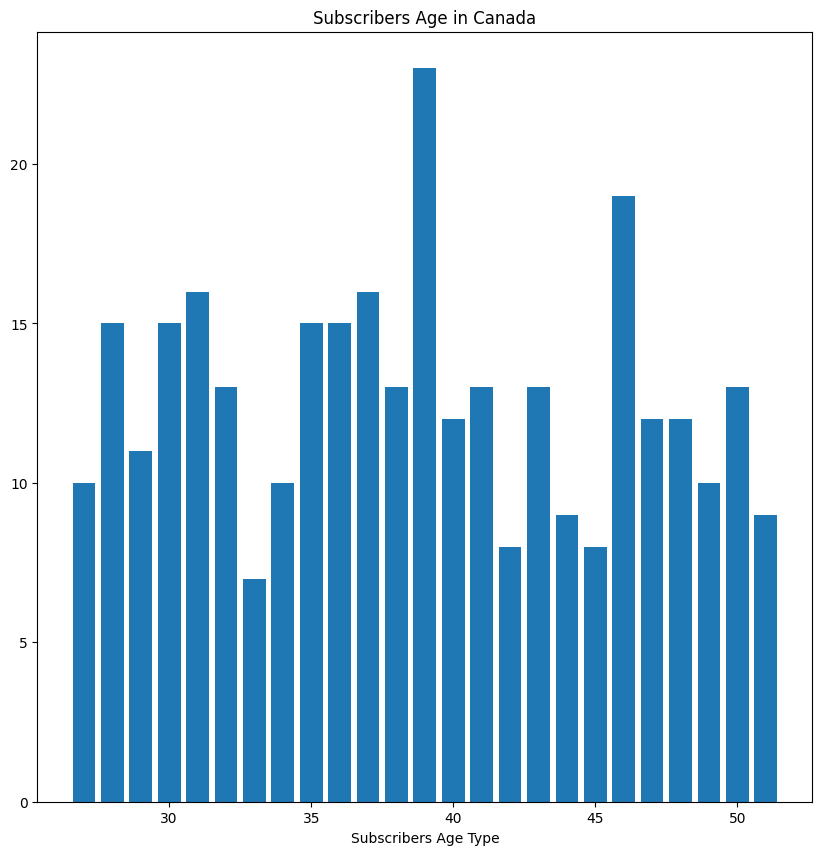

In [22]:
canada["age"]
plt.figure(figsize=(10,10))
plt.title("Subscribers Age in Canada")
plt.xlabel("Subscribers Age Type")
plt.ylabel("")
plt.bar(canada["age"].value_counts().index,canada["age"].value_counts().values)
plt.show()

In [29]:
female = canada[canada["gender"] == "Female"]

In [ ]:
female["subscription_type"].value_counts()

subscription_type
Basic       68
Standard    49
Premium     40
Name: count, dtype: int64

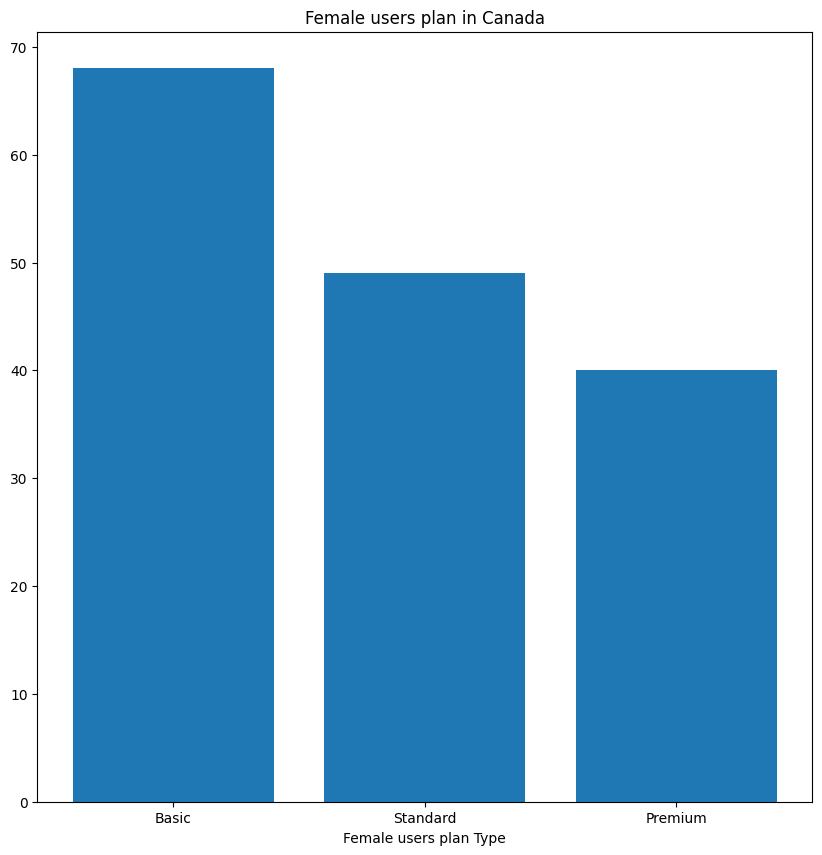

In [35]:
female["subscription_type"]
plt.figure(figsize=(10,10))
plt.title("Female users plan in Canada")
plt.xlabel("Female users plan Type")
plt.ylabel("")
plt.bar(female["subscription_type"].value_counts().index,female["subscription_type"].value_counts().values)
plt.show()

In [32]:
male = canada[canada["gender"] == "Male"]

In [33]:
male["subscription_type"].value_counts()

subscription_type
Basic       77
Premium     48
Standard    35
Name: count, dtype: int64

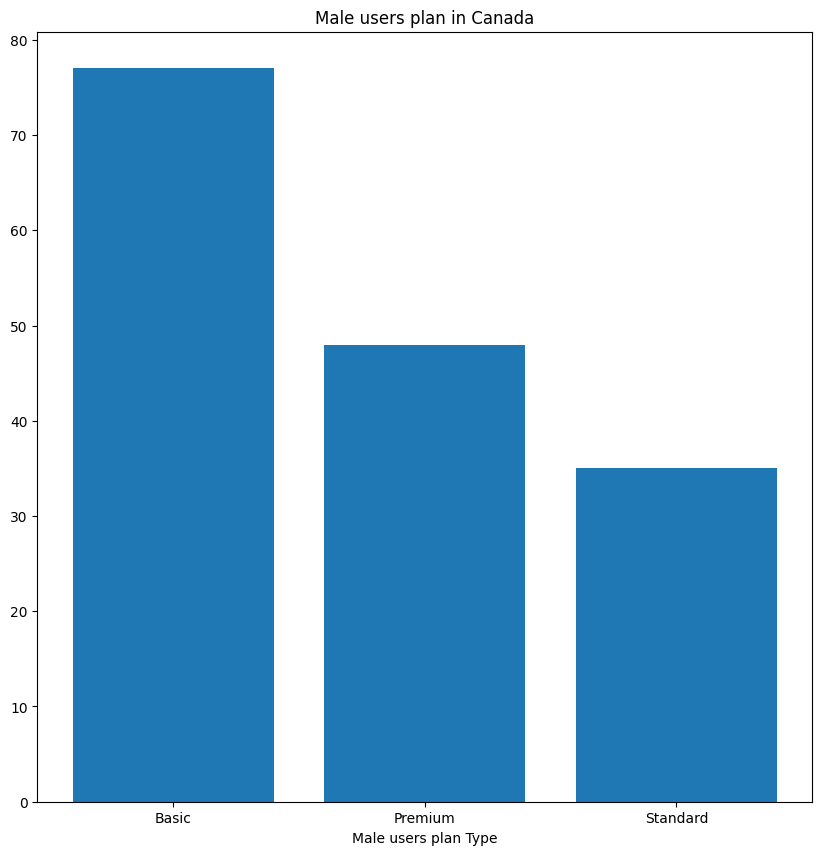

In [36]:
male["subscription_type"]
plt.figure(figsize=(10,10))
plt.title("Male users plan in Canada")
plt.xlabel("Male users plan Type")
plt.ylabel("")
plt.bar(male["subscription_type"].value_counts().index,male["subscription_type"].value_counts().values)
plt.show()

In [37]:
canada["device"].value_counts()

device
Tablet        95
Smartphone    80
Smart TV      78
Laptop        64
Name: count, dtype: int64

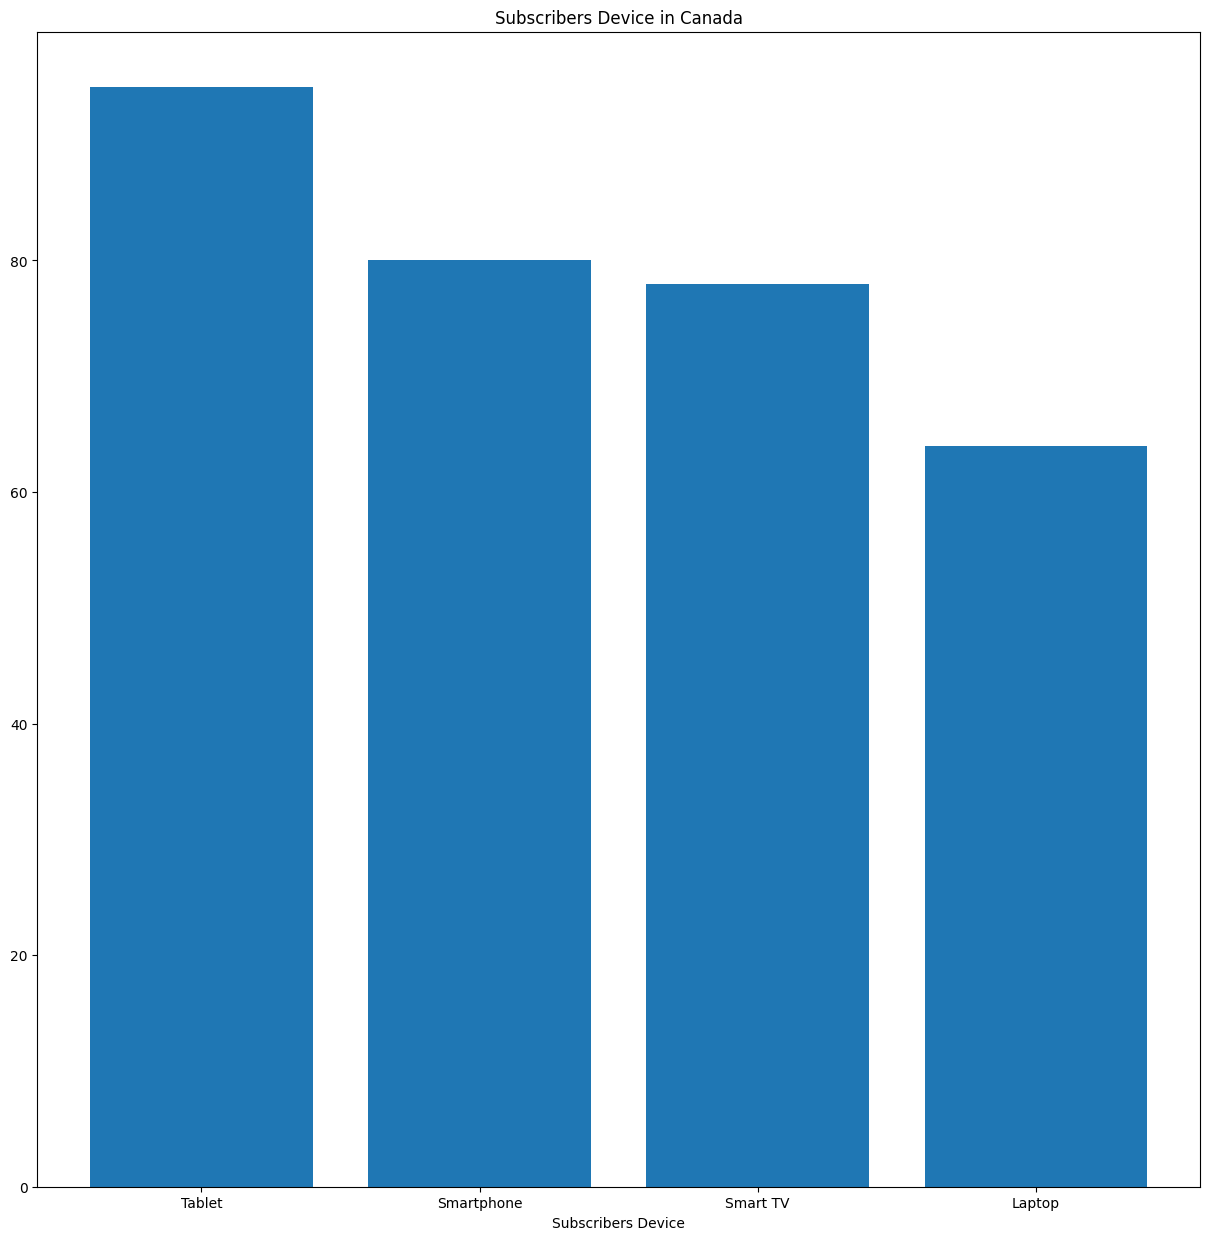

In [38]:
canada["device"].value_counts()
plt.figure(figsize=(15,15))
plt.title("Subscribers Device in Canada")
plt.xlabel("Subscribers Device")
plt.ylabel("")
plt.bar(canada["device"].value_counts().index,canada["device"].value_counts().values)
plt.show()

In [39]:
canada["subscribed_duration"].mean()

np.float64(323.2302839116719)

In [40]:
canada["subscribed_duration"].std()

np.float64(114.95637848070959)

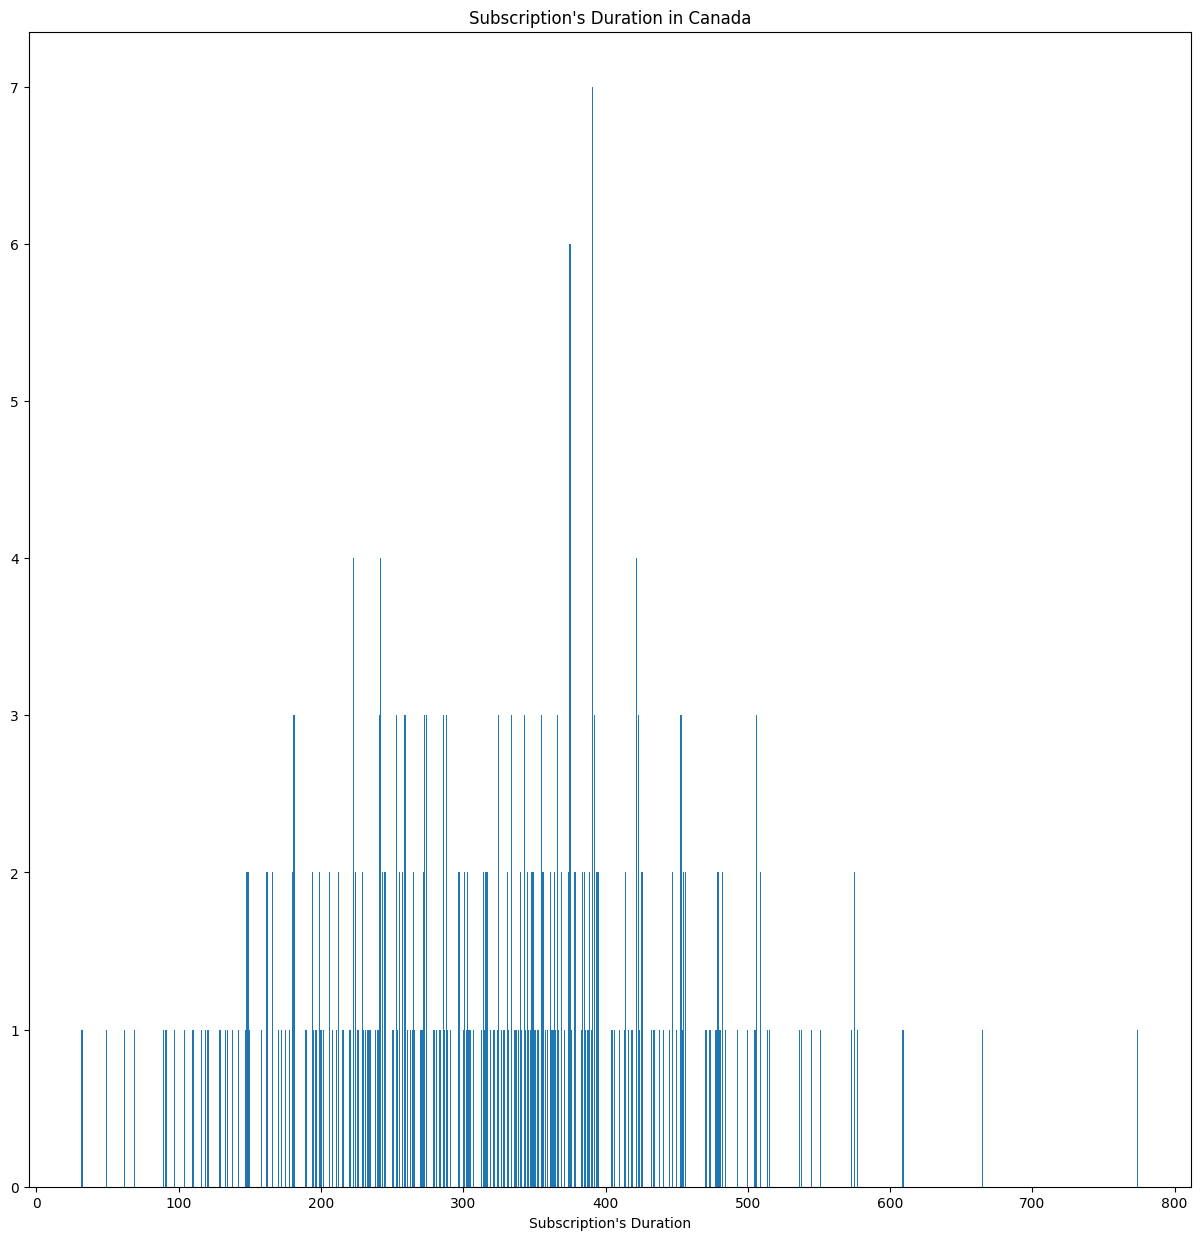

In [41]:
canada["subscribed_duration"]
plt.figure(figsize=(15,15))
plt.title("Subscription's Duration in Canada")
plt.xlabel("Subscription's Duration")
plt.ylabel("")
plt.bar(canada["subscribed_duration"].value_counts().index,canada["subscribed_duration"].value_counts().values)
plt.show()

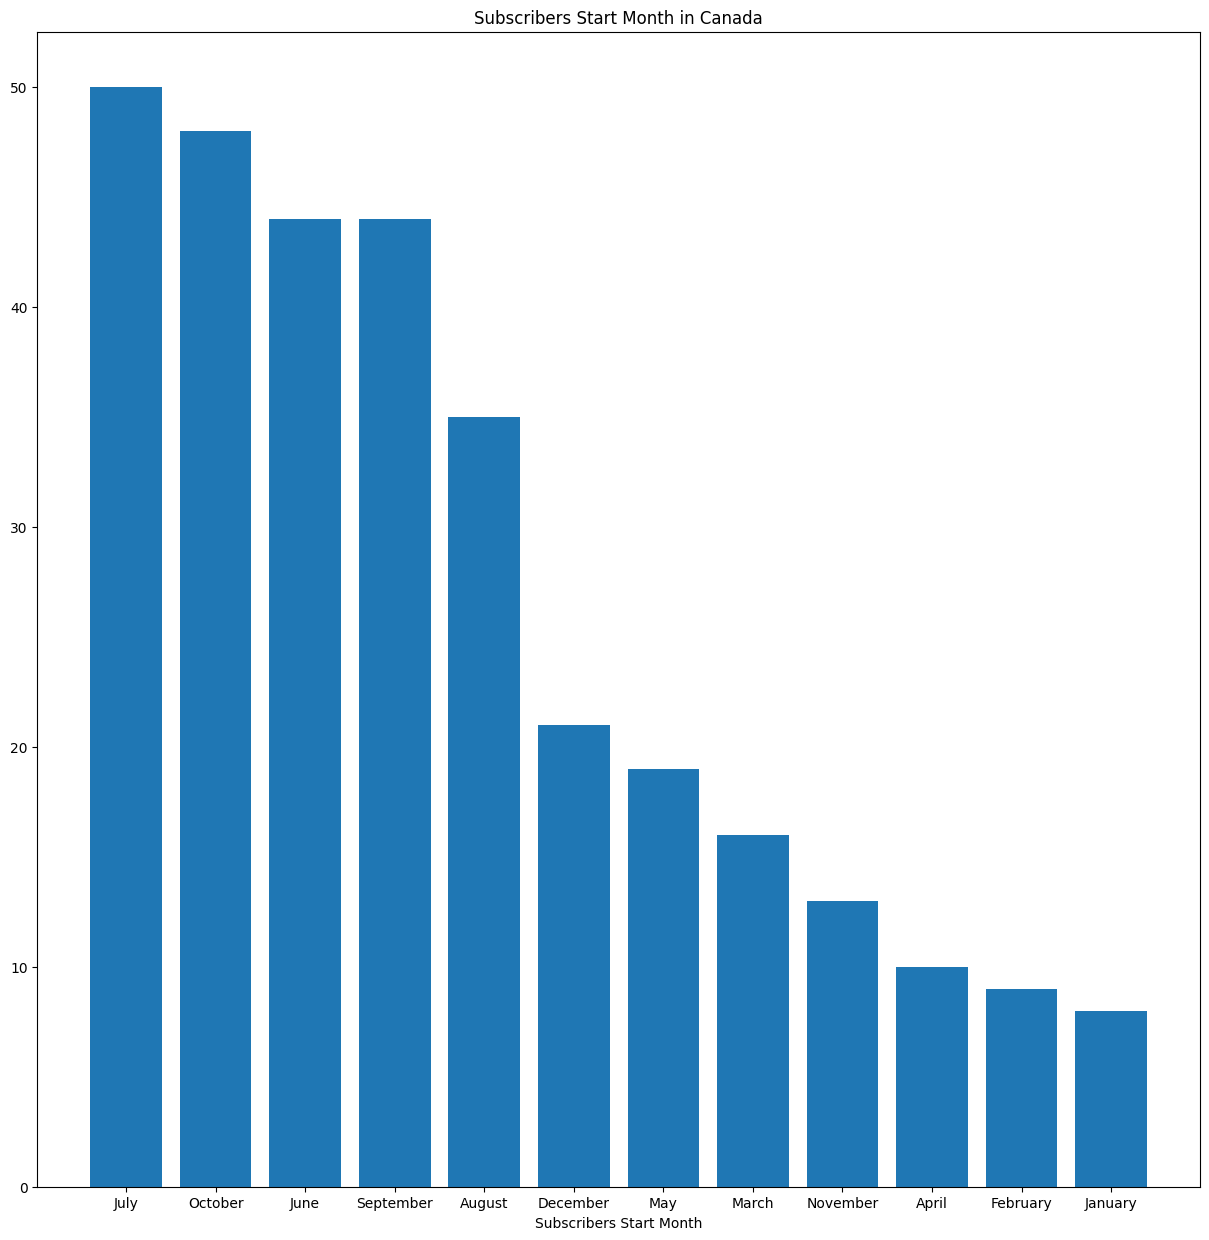

In [42]:
canada[["start_month"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscribers Start Month in Canada")
plt.xlabel("Subscribers Start Month")
plt.ylabel("")
plt.bar(canada["start_month"].value_counts().index,canada["start_month"].value_counts().values)
plt.show()

In [47]:
canada["clv"].mean()

np.float64(4014.01261829653)

In [48]:
canada["clv"].std()

np.float64(1506.778349164588)

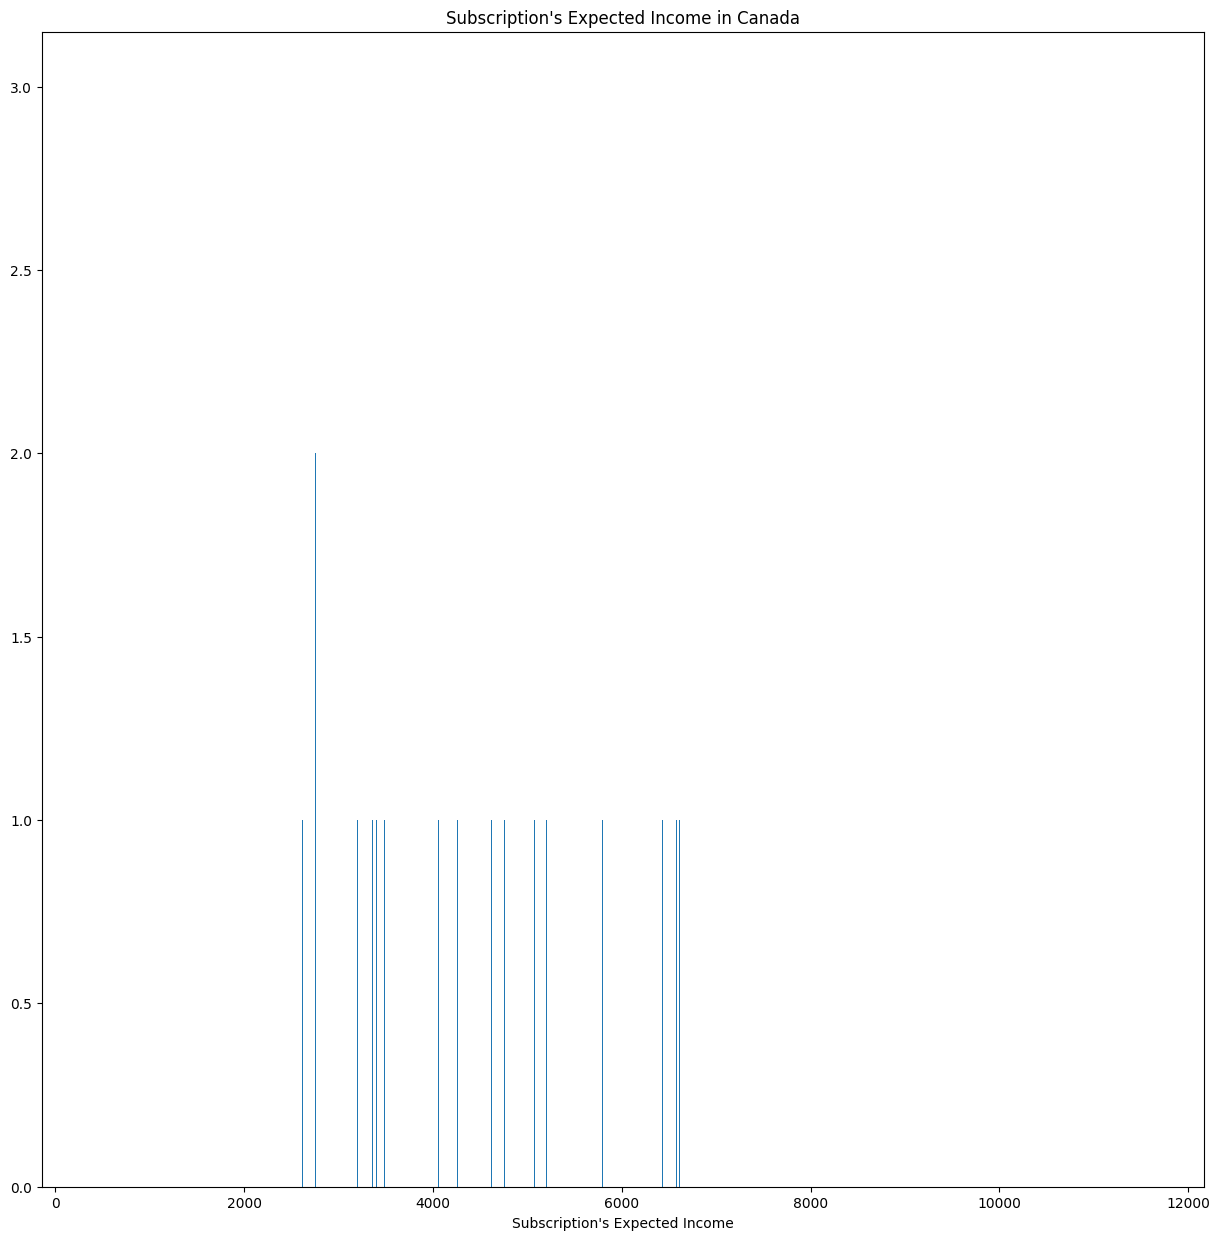

In [46]:
canada[["clv"]].count()
plt.figure(figsize=(15,15))
plt.title("Subscription's Expected Income in Canada")
plt.xlabel("Subscription's Expected Income")
plt.ylabel("")
plt.bar(canada["clv"].value_counts().index,canada["clv"].value_counts().values)
plt.show()

In [ ]:
## Subscription Type in Canada 💰

#Subscribed most of the prefer basic plan then premium plan and basic plan.

## Subscribers Age and Gender Analysis 🙍🏼‍♀️🙍🏼‍♂️

#There are more male subscribed than female subscribed.
#Male users prefer most of the basic plan.They prefer more premium plan than standart plan.
#Female users prefer most of the basic plan.They prefer more standart plan than premium plan. 
#Subscribers mean age is 38,standart deviation 7.Age distribution is ranges between 31-45.

## Subscribers Device Analysis 📱

#Subscribers device distribution is order by:"Tablet,Smartphone,Smart TV,Laptop".

## Subscription Duration Analysis 🛡

#Subscribers average number of payment days 323 days.Standart diviation is 114.
#Subscribers number of payment days ranges between 209-437 days.

## Subscription Start Date Analysis ⏰

#Subscribers usually joined first 5 months in netflix.

## Revenue Analysis Expected From Subscribers(Netflix) 💰

#Expected revenue mean 4014 💲 from subscribers.Standart diviation is 1506 💲.
#Expected revenue ranges between 2508-5520 💲.

In [ ]:
#For short
#I think canada is effiency bazaar for investment.

I dont analysis other country because other country is not effiency.